# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os, sys

os.chdir("/content/drive/MyDrive/K4-Track4-Day1-Neuralnetwork/submission_2A202602507/code")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print(os.getcwd())
print(os.listdir("../../data/processed"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/K4-Track4-Day1-Neuralnetwork/submission_2A202602507/code
['train.npz', 'eval.npz']


In [2]:
# Chạy ô này mỗi khi bạn sửa một file .py, rồi chạy lại ô có các dòng "from data import ..."
import importlib
for m in ["data", "model", "optimizer", "train", "plots", "results_table"]:
    if m in sys.modules:
        importlib.reload(sys.modules[m])
print("Đã nạp lại code")

Đã nạp lại code


In [3]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess
import numpy as np, torch

REPO_ROOT = "../.."     # thư mục gốc repo (chứa data/ và scripts/)
OUT_DIR   = ".."        # = submission_2A202602507/ (figures/, results/, experiments.xlsx, ...)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", device,
      "|", torch.cuda.get_device_name(0) if device == "cuda" else "")
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

torch 2.11.0+cu130 | device: cuda | Tesla T4


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [4]:
# ===== Part 0 — Chia dữ liệu, tách val, chuẩn hoá, đưa lên GPU =====
subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True)

D = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")

print({k: tuple(v.shape) for k, v in D.items() if hasattr(v, "shape")})
assert len(D["y_tr"]) == 371847 and len(D["y_val"]) == 92962 and len(D["y_eval"]) == 116203
assert D["X_tr"].dtype == torch.float32 and D["y_tr"].dtype == torch.int64

num = D["X_tr"][:, :10]
print("mean 10 cột số (≈0):", num.mean(0).cpu().numpy().round(3))
print("std  10 cột số (≈1):", num.std(0).cpu().numpy().round(3))
print("Part 0 OK ✅")

train: 371,847  val: 92,962  eval: 116,203
tỉ lệ lớp (%)
lớp   train     val    eval
  0  36.461  36.460  36.460
  1  48.760  48.760  48.760
  2   6.154   6.154   6.154
  3   0.473   0.472   0.472
  4   1.634   1.634   1.634
  5   2.989   2.989   2.989
  6   3.530   3.530   3.530
đoán luôn lớp đa số (lớp 1) -> accuracy trên val = 0.4876
{'X_tr': (371847, 54), 'y_tr': (371847,), 'X_val': (92962, 54), 'y_val': (92962,), 'X_eval': (116203, 54), 'y_eval': (116203,), 'eval_row_id': (116203,), 'mean': (10,), 'std': (10,)}
mean 10 cột số (≈0): [-0. -0.  0.  0.  0.  0. -0. -0. -0.  0.]
std  10 cột số (≈1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Part 0 OK ✅


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)
Số tham số: 47879
Linear   -> (8, 256)
ReLU     -> (8, 256)
Linear   -> (8, 128)
ReLU     -> (8, 128)
Linear   -> (8, 7)

Loss bước 0 trên val = 2.3776   (ln 7 = 1.9459)
std kích hoạt bước 0 [ReLU1, ReLU2, logit]: [0.414, 0.379, 0.649]

Quá khớp 20 mẫu: loss đầu 1.9668 -> loss cuối 0.000267, accuracy = 100%


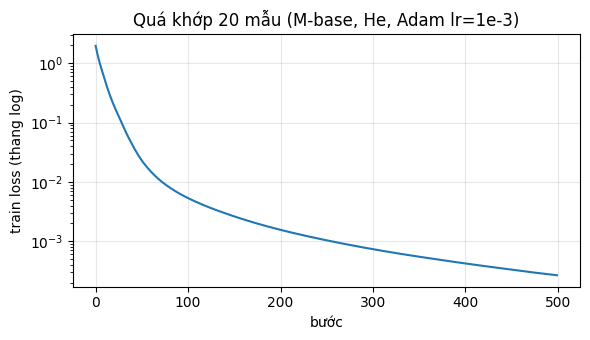


W1  (256, 54)    grad norm = 5.8230e-01
b1  (256,)       grad norm = 3.8331e-01
W2  (128, 256)   grad norm = 2.3717e+00
b2  (128,)       grad norm = 4.9814e-01
W3  (7, 128)     grad norm = 2.0783e+00
b3  (7,)         grad norm = 6.0607e-01

Part 1 OK ✅


In [5]:
import importlib, math
import model as model_mod
importlib.reload(model_mod)
from model import MLP, EXPECTED_PARAMS, count_params, activation_stats
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt

# ---- TODO 1: tạo model, kiểm tra số tham số ----
torch.manual_seed(42)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
n_params = count_params(model)
print(model)
print("Số tham số:", n_params)
assert n_params == EXPECTED_PARAMS[(256, 128)] == 47_879

# ---- TODO 2: shape qua từng lớp ----
x = torch.randn(8, 54, device=device)
h = x
for layer in model.net:
    h = layer(h)
    print(f"{layer.__class__.__name__:8s} -> {tuple(h.shape)}")
assert model(x).shape == (8, 7)

# ---- TODO 3: loss bước 0 trên val ----
model.eval()
with torch.no_grad():
    loss0 = F.cross_entropy(model(D["X_val"]), D["y_val"]).item()
print(f"\nLoss bước 0 trên val = {loss0:.4f}   (ln 7 = {math.log(7):.4f})")
print("std kích hoạt bước 0 [ReLU1, ReLU2, logit]:",
      [round(s, 3) for s in activation_stats(model, D["X_val"][:4096])])

# ---- TODO 4: quá khớp 20 mẫu ----
torch.manual_seed(0)
tiny = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
x20, y20 = D["X_tr"][:20], D["y_tr"][:20]
opt = torch.optim.Adam(tiny.parameters(), lr=1e-3)
hist = []
tiny.train()
for step in range(500):
    opt.zero_grad()
    loss = F.cross_entropy(tiny(x20), y20)
    loss.backward()
    opt.step()
    hist.append(loss.item())
tiny.eval()
with torch.no_grad():
    acc20 = (tiny(x20).argmax(1) == y20).float().mean().item()
print(f"\nQuá khớp 20 mẫu: loss đầu {hist[0]:.4f} -> loss cuối {hist[-1]:.6f}, accuracy = {acc20:.0%}")

plt.figure(figsize=(6, 3.5))
plt.semilogy(hist)
plt.xlabel("bước"); plt.ylabel("train loss (thang log)")
plt.title("Quá khớp 20 mẫu (M-base, He, Adam lr=1e-3)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ---- TODO 5: gradient chảy tới mọi tham số ----
model.train()
model.zero_grad()
F.cross_entropy(model(D["X_tr"][:512]), D["y_tr"][:512]).backward()
ten = {"net.0.weight": "W1", "net.0.bias": "b1", "net.2.weight": "W2",
       "net.2.bias": "b2", "net.4.weight": "W3", "net.4.bias": "b3"}
print()
for name, p in model.named_parameters():
    g = p.grad
    assert g is not None and g.norm().item() > 0, f"{name} không có gradient!"
    print(f"{ten.get(name, name):3s} {str(tuple(p.shape)):12s} grad norm = {g.norm().item():.4e}")
print("\nPart 1 OK ✅")

**Nhận xét Part 1**

- **Shape và số tham số:** model có đúng 47 879 tham số (assert qua), đầu ra lô (8, 54) là logits (8, 7); không có softmax trong model.
- **Loss bước 0 = 2,3776**, cao hơn ln 7 = 1,9459 khoảng 0,43. ln 7 chỉ đúng khi mọi logit gần bằng nhau (dự đoán đều 1/7). Với khởi tạo He (Var = 2/n_in, áp dụng cả cho lớp ra), logit ở bước 0 có std = 0,649, không nhỏ. Thêm vào đó, đầu ra ReLU luôn ≥ 0 nên có trung bình dương; vì vậy logit của mỗi lớp c (= Σ_j h_j·W_jc) bị cộng một **độ lệch cố định giống nhau cho mọi mẫu**. Model khởi đầu đã "thiên vị" ngẫu nhiên vài lớp; nếu lớp được thiên vị là lớp hiếm thì loss trung bình tăng lên. Mức lệch này đến từ cách khởi tạo, không phải lỗi pipeline: lỗi nhãn lệch hay softmax hai lần sẽ khiến bài quá khớp 20 mẫu thất bại, mà ở đây bài đó thành công. (Nếu khởi tạo lớp ra nhỏ hơn, ví dụ Xavier hoặc mặc định, loss bước 0 sẽ về gần ln 7.)
- **Quá khớp 20 mẫu:** loss giảm từ 1,9668 xuống 0,000267 sau 500 bước Adam (lr = 1e-3), accuracy 100%. Đường loss trên thang log giảm đều, không dao động, chứng tỏ forward, backward, zero_grad và optimizer đều hoạt động đúng; model đủ năng lực ghi nhớ một lô nhỏ.
- **Gradient:** cả 6 tensor W1, b1, W2, b2, W3, b3 đều có grad norm khác 0 (từ 0,38 đến 2,37), nên gradient chảy được tới mọi lớp, không có lớp "chết" ở bước đầu.
- **Kết luận:** pipeline đã qua cả ba phép thử sức khoẻ (loss bước 0 hợp lý và giải thích được, quá khớp được lô nhỏ, gradient chảy). Nếu sau này loss huấn luyện không giảm, lỗi nhiều khả năng nằm ở siêu tham số (lr, batch) hơn là ở code model.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [6]:
import importlib, os
import numpy as np
import optimizer as opt_mod, train as train_mod, plots as plots_mod, results_table as rt_mod
for m in (opt_mod, train_mod, plots_mod, rt_mod):
    importlib.reload(m)
from train import DEFAULT_CFG, run_experiment
from plots import plot_run, plot_compare
from results_table import save_result

OUT_DIR = ".."
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)
RESULTS = {}   # exp_id -> result (giữ cả best_state trong RAM)

def run_and_save(cfg, show=False):
    """Chạy 1 thí nghiệm, lưu results/<exp_id>.json và figures/<exp_id>.png."""
    r = run_experiment(cfg, D)
    exp_id = r["cfg"]["exp_id"]
    RESULTS[exp_id] = r
    save_result(r, f"{OUT_DIR}/results")
    plot_run(r, f"{OUT_DIR}/figures/{exp_id}.png", show=show)
    return r

print("Sẵn sàng. Thiết bị:", D["X_tr"].device)

Sẵn sàng. Thiết bị: cuda:0


[hp-sgdm-lr0.01] 47,879 tham số | loss bước 0 (val) = 2.2691 | 727 bước/epoch
  ep  1 | train 0.5751 | val 0.5803 | acc 0.7560 | mF1 0.4941 | gn 0.437 | 1.4s *
  ep  2 | train 0.5257 | val 0.5294 | acc 0.7758 | mF1 0.5824 | gn 0.504 | 1.5s *
  ep  3 | train 0.4904 | val 0.4947 | acc 0.7906 | mF1 0.5968 | gn 0.603 | 1.5s *
  ep  4 | train 0.4695 | val 0.4727 | acc 0.8000 | mF1 0.6280 | gn 0.705 | 1.3s *
  ep  5 | train 0.4455 | val 0.4502 | acc 0.8089 | mF1 0.6427 | gn 0.798 | 1.2s *
  ep  6 | train 0.4263 | val 0.4303 | acc 0.8201 | mF1 0.6656 | gn 0.888 | 1.3s *
  ep  7 | train 0.4125 | val 0.4175 | acc 0.8252 | mF1 0.6798 | gn 0.915 | 1.2s *
  ep  8 | train 0.4024 | val 0.4065 | acc 0.8309 | mF1 0.6791 | gn 1.025 | 1.3s *
  ep  9 | train 0.3863 | val 0.3921 | acc 0.8387 | mF1 0.6941 | gn 1.042 | 1.3s *
  ep 10 | train 0.3757 | val 0.3816 | acc 0.8431 | mF1 0.7180 | gn 1.178 | 1.3s *
  ep 11 | train 0.3668 | val 0.3739 | acc 0.8446 | mF1 0.7131 | gn 1.141 | 1.3s *
  ep 12 | train 0.35

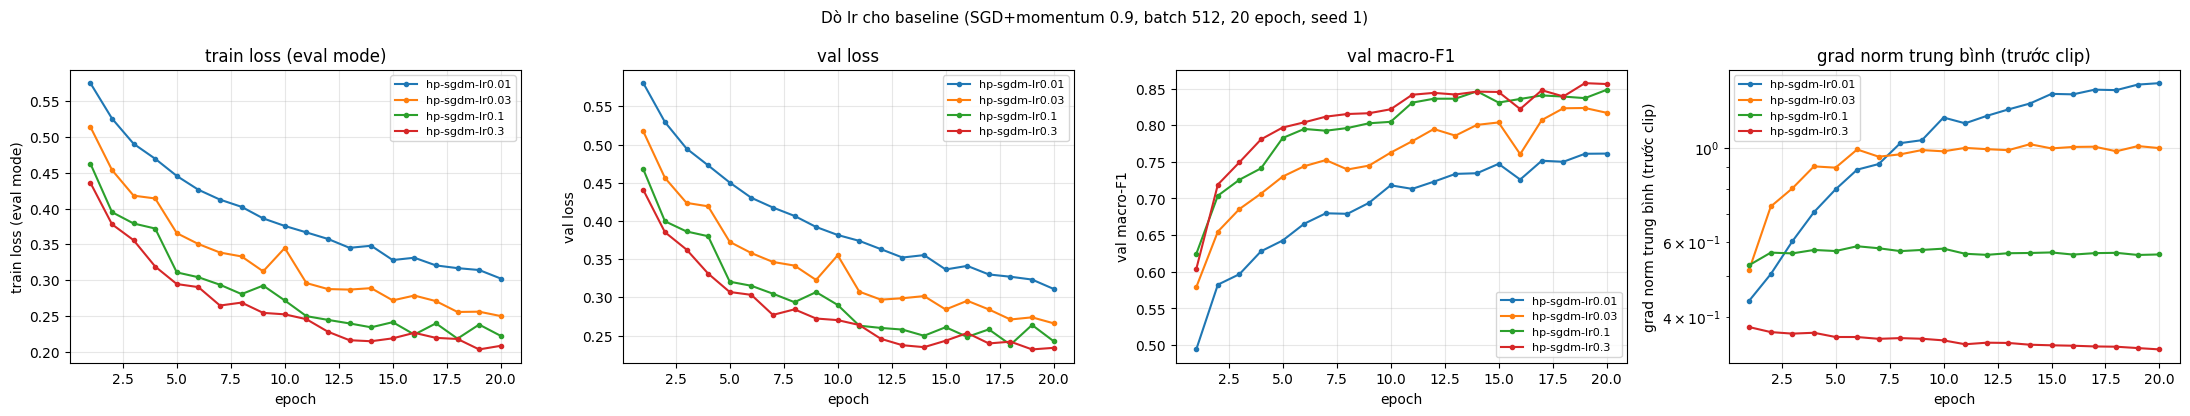


=> lr baseline chọn theo val macro-F1: 0.3


In [7]:
LRS = [0.01, 0.03, 0.1, 0.3]

for lr in LRS:
    run_and_save({**DEFAULT_CFG, "lr": lr, "seed": 1,
                  "exp_id": f"hp-sgdm-lr{lr:g}", "group": "hparam-lr",
                  "description": f"Dò lr baseline: SGD+momentum lr={lr:g}"})

print(f"\n{'lr':>6} | {'best ep':>7} | {'val loss':>8} | {'val acc':>7} | {'val mF1':>7} | diverged")
for lr in LRS:
    s = RESULTS[f"hp-sgdm-lr{lr:g}"]["summary"]
    print(f"{lr:>6g} | {str(s['best_epoch']):>7} | {s['best_val_loss']:8.4f} | "
          f"{s['val_acc']:7.4f} | {s['val_macro_f1']:7.4f} | {s['diverged']}")

plot_compare([RESULTS[f"hp-sgdm-lr{lr:g}"] for lr in LRS],
             ["train_loss", "val_loss", "val_macro_f1", "grad_norm"],
             f"{OUT_DIR}/figures/compare_lr_sgdm.png",
             title="Dò lr cho baseline (SGD+momentum 0.9, batch 512, 20 epoch, seed 1)", show=True)

# Chọn lr bằng VAL macro-F1 (không nhìn eval). Lần chạy diverged coi như -1.
def _score(lr):
    f1 = RESULTS[f"hp-sgdm-lr{lr:g}"]["summary"]["val_macro_f1"]
    return -1.0 if f1 is None or np.isnan(f1) else f1

BEST_LR = max(LRS, key=_score)
BASE_CFG = {**DEFAULT_CFG, "lr": BEST_LR}
print(f"\n=> lr baseline chọn theo val macro-F1: {BEST_LR}")

[base-s1] 47,879 tham số | loss bước 0 (val) = 2.2691 | 727 bước/epoch
  ep  1 | train 0.4360 | val 0.4404 | acc 0.8127 | mF1 0.6037 | gn 0.379 | 1.5s *
  ep  2 | train 0.3781 | val 0.3852 | acc 0.8383 | mF1 0.7190 | gn 0.369 | 1.3s *
  ep  3 | train 0.3559 | val 0.3625 | acc 0.8464 | mF1 0.7494 | gn 0.365 | 1.3s *
  ep  4 | train 0.3191 | val 0.3310 | acc 0.8650 | mF1 0.7807 | gn 0.367 | 1.3s *
  ep  5 | train 0.2946 | val 0.3070 | acc 0.8748 | mF1 0.7968 | gn 0.359 | 1.3s *
  ep  6 | train 0.2904 | val 0.3032 | acc 0.8760 | mF1 0.8039 | gn 0.359 | 1.2s *
  ep  7 | train 0.2646 | val 0.2770 | acc 0.8860 | mF1 0.8116 | gn 0.355 | 1.3s *
  ep  8 | train 0.2688 | val 0.2842 | acc 0.8847 | mF1 0.8152 | gn 0.357 | 1.7s
  ep  9 | train 0.2544 | val 0.2722 | acc 0.8899 | mF1 0.8163 | gn 0.355 | 1.9s *
  ep 10 | train 0.2524 | val 0.2702 | acc 0.8899 | mF1 0.8217 | gn 0.352 | 1.5s *
  ep 11 | train 0.2456 | val 0.2638 | acc 0.8944 | mF1 0.8415 | gn 0.345 | 1.4s *
  ep 12 | train 0.2281 | val 

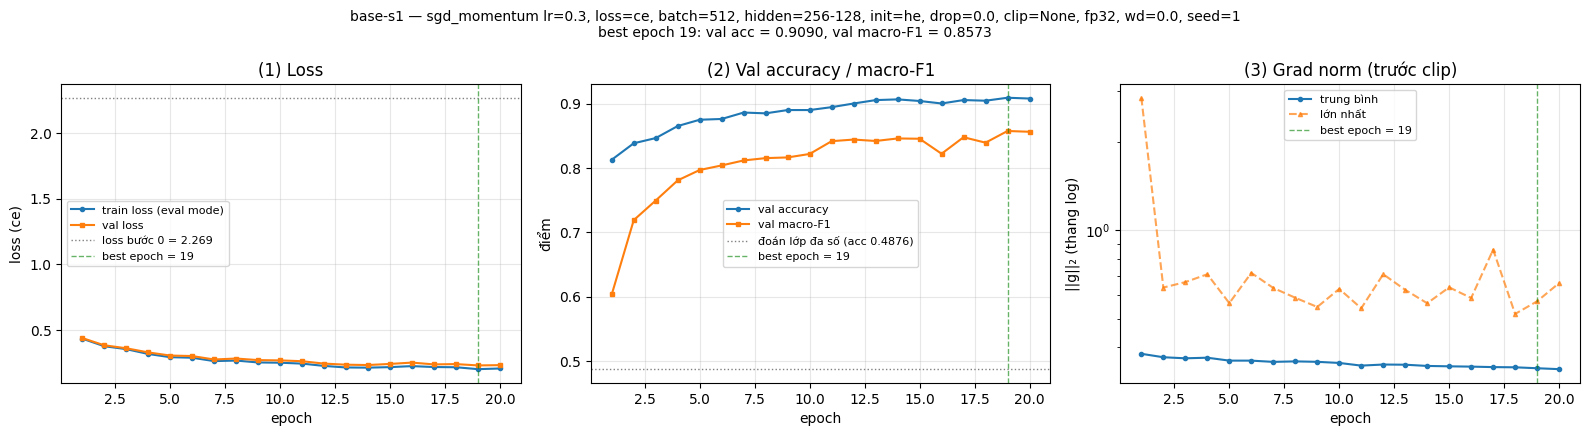

[base-s2] 47,879 tham số | loss bước 0 (val) = 1.9782 | 727 bước/epoch
  ep  1 | train 0.4433 | val 0.4477 | acc 0.8100 | mF1 0.6842 | gn 0.380 | 1.4s *
  ep  2 | train 0.3648 | val 0.3739 | acc 0.8438 | mF1 0.7408 | gn 0.361 | 1.3s *
  ep  3 | train 0.3343 | val 0.3429 | acc 0.8596 | mF1 0.7828 | gn 0.358 | 1.4s *
  ep  4 | train 0.3096 | val 0.3194 | acc 0.8673 | mF1 0.7880 | gn 0.358 | 1.4s *
  ep  5 | train 0.2856 | val 0.2956 | acc 0.8805 | mF1 0.8136 | gn 0.353 | 1.4s *
  ep  6 | train 0.2801 | val 0.2912 | acc 0.8817 | mF1 0.8098 | gn 0.350 | 1.4s *
  ep  7 | train 0.2630 | val 0.2780 | acc 0.8863 | mF1 0.8178 | gn 0.350 | 1.3s *
  ep  8 | train 0.2548 | val 0.2709 | acc 0.8913 | mF1 0.8182 | gn 0.347 | 1.5s *
  ep  9 | train 0.2582 | val 0.2762 | acc 0.8893 | mF1 0.8299 | gn 0.346 | 1.5s
  ep 10 | train 0.2386 | val 0.2555 | acc 0.8955 | mF1 0.8309 | gn 0.341 | 1.4s *
  ep 11 | train 0.2263 | val 0.2441 | acc 0.9016 | mF1 0.8422 | gn 0.341 | 1.2s *
  ep 12 | train 0.2209 | val 

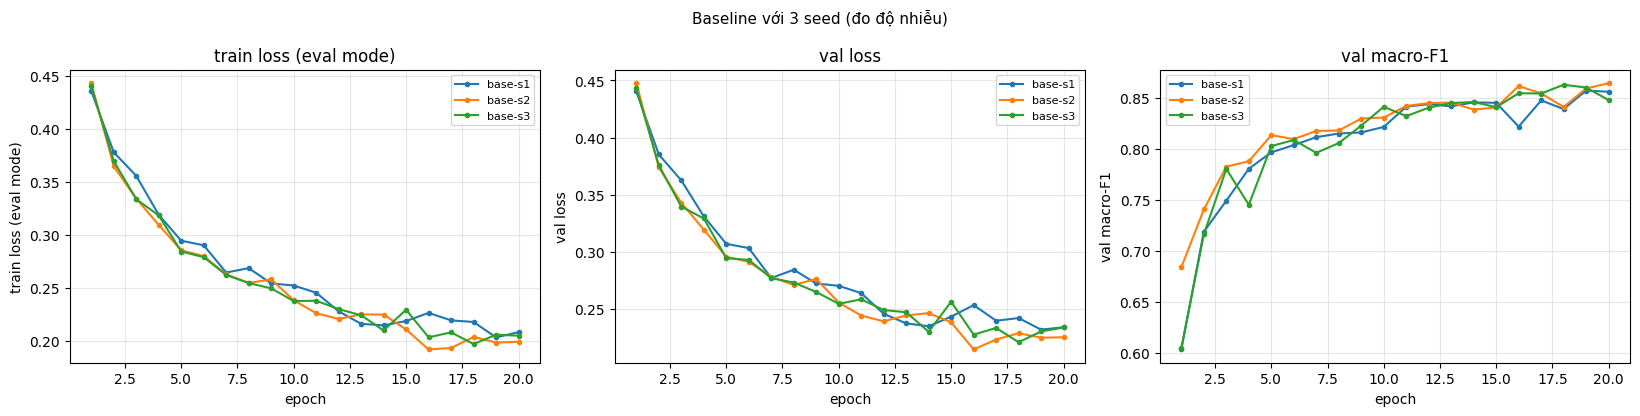

In [8]:
SEEDS = [1, 2, 3]
for s in SEEDS:
    run_and_save({**BASE_CFG, "seed": s, "exp_id": f"base-s{s}", "group": "baseline",
                  "description": f"Baseline M-base, lr={BEST_LR:g}, seed {s}"},
                 show=(s == 1))

rows = [RESULTS[f"base-s{s}"]["summary"] for s in SEEDS]
f1 = np.array([r["val_macro_f1"] for r in rows])
acc = np.array([r["val_acc"] for r in rows])
vl = np.array([r["best_val_loss"] for r in rows])

print(f"\n{'exp_id':8} | best ep | val loss | val acc | val mF1 | s/epoch")
for s, r in zip(SEEDS, rows):
    print(f"base-s{s:<3} | {r['best_epoch']:>7} | {r['best_val_loss']:.4f} | {r['val_acc']:.4f} | "
          f"{r['val_macro_f1']:.4f} | {r['time_per_epoch_s']:.2f}")
print(f"\nval macro-F1 = {f1.mean():.4f} ± {f1.std(ddof=1):.4f}  -> ngưỡng nhiễu 2σ = {2*f1.std(ddof=1):.4f}")
print(f"val acc      = {acc.mean():.4f} ± {acc.std(ddof=1):.4f}  -> ngưỡng nhiễu 2σ = {2*acc.std(ddof=1):.4f}")
print(f"val loss     = {vl.mean():.4f} ± {vl.std(ddof=1):.4f}")
NOISE_F1 = 2 * f1.std(ddof=1)
BASE_F1_MEAN = f1.mean()

plot_compare([RESULTS[f"base-s{s}"] for s in SEEDS],
             ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_baseline_seeds.png",
             title=f"Baseline với {len(SEEDS)} seed (đo độ nhiễu)", show=True)

**Nhận xét Part 2 — dò lr và baseline**

**1. Dò lr (SGD+momentum 0.9, batch 512, 20 epoch, seed 1; ảnh `compare_lr_sgdm.png`)**

| lr | best epoch | val loss | val acc | val macro-F1 |
|---|---|---|---|---|
| 0.01 (`hp-sgdm-lr0.01`) | 20 | 0.3110 | 0.8747 | 0.7613 |
| 0.03 (`hp-sgdm-lr0.03`) | 20 | 0.2660 | 0.8921 | 0.8170 |
| 0.1 (`hp-sgdm-lr0.1`) | 18 | 0.2379 | 0.9054 | 0.8390 |
| 0.3 (`hp-sgdm-lr0.3`) | 19 | 0.2318 | 0.9090 | **0.8573** |

- lr càng lớn thì loss giảm càng nhanh và điểm càng cao trong cùng 20 epoch. Với SGD, mỗi bước dịch chuyển tỉ lệ với lr (và với momentum 0,9, bước hiệu dụng ≈ lr/(1−0,9) = 10·lr), nên lr nhỏ cần nhiều bước hơn để đi cùng quãng đường. Bằng chứng: lr = 0,01 và 0,03 có best epoch = 20, tức là **vẫn đang giảm, chưa hội tụ** khi hết 20 epoch.
- Chọn **lr = 0,3** theo val macro-F1 (không dùng eval). Chênh lệch giữa 0,3 và 0,1 là 0,018, lớn hơn ngưỡng nhiễu 2σ = 0,006 đo ở mục 3, nên khác biệt này có ý nghĩa. Hạn chế: 0,3 là giá trị **lớn nhất** đã thử, nên lr tối ưu có thể còn lớn hơn; mình chưa thử 1,0.
- Quan sát về grad norm: lr càng nhỏ thì grad norm trung bình càng lớn và còn tăng dần theo epoch (lr = 0,01 lên ≈ 1,2), trong khi lr = 0,3 giữ ở ≈ 0,33. Phần đo được là: lr nhỏ thì loss còn cao, nên gradient còn lớn. *Phỏng đoán (chưa kiểm chứng):* với lr lớn, SGD không thể đứng yên ở vùng có độ cong lớn (bước nhảy sẽ vượt qua đáy) nên bị đẩy về vùng phẳng hơn, nơi gradient nhỏ hơn.

**2. Baseline (`base-s1`, `base-s2`, `base-s3`; lr = 0,3; ảnh `base-s1.png`, `compare_baseline_seeds.png`)**

- Loss bước 0 của `base-s1` = 2,269 (giải thích ở Part 1: khởi tạo He cho logit ban đầu lệch theo lớp).
- **Hình dạng đường cong:** loss giảm nhanh trong ~5 epoch đầu (0,44 → 0,30), sau đó giảm chậm. Train loss (đo ở eval mode trên 50 000 mẫu train cố định) và val loss gần như trùng nhau (cuối: ≈ 0,205 so với ≈ 0,23), khoảng cách nhỏ, nên **chưa có dấu hiệu quá khớp**. Best epoch rơi vào 16–19, gần cuối, nên model vẫn còn học được thêm; nhiều epoch hơn hoặc giảm lr dần về cuối có thể còn cải thiện (sẽ thử ở Part 3).
- Val loss có răng cưa giữa các epoch (ví dụ `base-s1`: macro-F1 tụt xuống ≈ 0,82 ở epoch 16 rồi hồi lại). Với lr = 0,3 khá lớn, mỗi bước SGD nhảy quanh đáy chứ không dừng hẳn; đây là cái giá của việc dùng lr lớn để học nhanh.
- **So với mốc "đoán đa số":** val accuracy 0,912 so với 0,4876, vượt rất xa. Macro-F1 (0,861) thấp hơn accuracy (0,912) vì macro-F1 cho mỗi lớp trọng số như nhau, nên các lớp hiếm (lớp 3 chỉ ≈ 0,5% dữ liệu) kéo điểm xuống; accuracy thì bị lớp 0 và lớp 1 (≈ 85% dữ liệu) chi phối.
- **Grad norm:** epoch 1 có gai lớn nhất ≈ 2,5 (giai đoạn đầu khi loss còn cao), sau đó grad norm lớn nhất mỗi epoch dao động 0,4–0,7, trung bình ổn định ≈ 0,33–0,34. Con số này sẽ là căn cứ để chọn ngưỡng c ở thí nghiệm gradient clipping.
- Thời gian: ≈ 1,3 s/epoch trên T4 (727 bước/epoch).

**3. Độ nhiễu giữa các seed**

| exp_id | best epoch | val loss | val acc | val macro-F1 |
|---|---|---|---|---|
| `base-s1` | 19 | 0.2318 | 0.9090 | 0.8573 |
| `base-s2` | 16 | 0.2145 | 0.9144 | 0.8618 |
| `base-s3` | 18 | 0.2208 | 0.9121 | 0.8630 |
| **trung bình ± std** | | 0.2224 ± 0.0088 | 0.9118 ± 0.0027 | **0.8607 ± 0.0030** |

- **Ngưỡng nhiễu 2σ: macro-F1 = 0,0060, accuracy = 0,0054.** Ở Part 3, mọi thí nghiệm chỉ được coi là "tốt hơn / tệ hơn baseline" khi chênh lệch macro-F1 so với trung bình 0,8607 lớn hơn 0,006; nhỏ hơn thì ghi là chưa kết luận được.
- Hạn chế: chỉ có 3 seed nên ước lượng độ lệch chuẩn còn thô. Ngoài ra, dao động giữa các epoch trong cùng một lần chạy (ví dụ cú tụt ở epoch 16 của `base-s1`) lớn hơn cả nhiễu giữa seed, nên điểm "ở best epoch" bản thân nó đã mang nhiễu.
- Ghi chú: `base-s1` và `hp-sgdm-lr0.3` cùng cấu hình (seed 1) nên cho cùng kết quả; trong bảng xlsx sẽ ghi rõ ở cột notes.

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Thiết kế chung cho các thí nghiệm Part 3

- **Cấu hình gốc:** `BASE_CFG` = baseline đã chọn ở Part 2 (M-base 54-256-128-7, He init, cross-entropy, SGD+momentum 0,9, lr chọn bằng val, batch 512, 20 epoch, không dropout, không clip, FP32).
- **Công bằng:** mọi thí nghiệm dùng **seed 1**, cùng phép tách validation (20% train, phân tầng, seed 42), cùng 20 epoch, và **chỉ đổi một yếu tố** so với `BASE_CFG`. Trường hợp đổi nhiều yếu tố cùng lúc được ghi rõ trong `description`.
- **So sánh:** mỗi thí nghiệm được so với `base-s1` (cùng seed) và với trung bình 3 seed baseline. Một khác biệt chỉ được kết luận là "tốt hơn / tệ hơn" khi chênh lệch val macro-F1 lớn hơn **ngưỡng nhiễu 2σ** đo ở Part 2; nhỏ hơn thì ghi là "trong nhiễu".
- **Chọn cấu hình chỉ bằng val**, không dùng tập eval.
- **Sản phẩm:** mỗi lần chạy lưu `results/<exp_id>.json` và `figures/<exp_id>.png`; mỗi nhóm có thêm ảnh chồng `figures/compare_<nhóm>.png`.
- **Quy ước:** mỗi chủ đề gồm ô **Dự đoán trước** (viết trước khi chạy) → ô code → ô **Đối chiếu sau khi chạy**.

In [9]:
# ===== Part 3 — công cụ chung cho mọi thí nghiệm =====
import importlib, torch, numpy as np
import torch.nn.functional as F
import model as model_mod
importlib.reload(model_mod)
from model import MLP, activation_stats

REF = "base-s1"                 # mọi thí nghiệm dùng seed 1 -> so trực tiếp với base-s1
SKIPPED = {}                    # exp_id -> lý do không chạy được (ghi vào notes của bảng)

def run_group(group, cfgs, metrics=("train_loss", "val_loss", "val_macro_f1", "grad_norm"),
              title="", include_ref=True):
    """Chạy một nhóm thí nghiệm: mỗi cfg chỉ ghi phần KHÁC baseline. Lưu JSON + ảnh từng lần chạy,
    in bảng so với baseline, vẽ ảnh chồng figures/compare_<group>.png."""
    ids = []
    for c in cfgs:
        cfg = {**BASE_CFG, "seed": 1, "group": group, **c}
        try:
            run_and_save(cfg)
            ids.append(cfg["exp_id"])
        except Exception as e:               # ví dụ GPU không hỗ trợ bf16
            SKIPPED[cfg["exp_id"]] = f"{type(e).__name__}: {e}"
            print(f"!! {cfg['exp_id']} KHÔNG chạy được: {SKIPPED[cfg['exp_id']]}")
    report(ids)
    show = [RESULTS[REF]] if include_ref else []
    show += [RESULTS[i] for i in ids]
    plot_compare(show, list(metrics), f"{OUT_DIR}/figures/compare_{group}.png",
                 title=title or f"Nhóm {group} (so với {REF})", show=True)
    return ids

def report(ids, ref=REF):
    """Bảng so sánh với baseline: Δ macro-F1 so với trung bình 3 seed, và có vượt ngưỡng 2σ không."""
    r0 = RESULTS[ref]["summary"]
    print(f"\nNgưỡng nhiễu 2σ (macro-F1) = {NOISE_F1:.4f}; baseline: {ref} mF1 = {r0['val_macro_f1']:.4f}, "
          f"trung bình 3 seed = {BASE_F1_MEAN:.4f}")
    print(f"{'exp_id':24} | best ep | val loss | val acc | val mF1 | Δ vs mean | vượt 2σ? | s/ep | MB | div")
    for i in [ref] + list(ids):
        s = RESULTS[i]["summary"]
        f1 = s["val_macro_f1"]
        if f1 is None or np.isnan(f1):
            d, verdict = float("nan"), "—"
        else:
            d = f1 - BASE_F1_MEAN
            verdict = ("tốt hơn" if d > NOISE_F1 else "tệ hơn" if d < -NOISE_F1 else "trong nhiễu")
        print(f"{i:24} | {str(s['best_epoch']):>7} | {s['best_val_loss']:8.4f} | {s['val_acc']:.4f} | "
              f"{f1:.4f} | {d:+9.4f} | {verdict:>8} | {s['time_per_epoch_s']:.2f} | "
              f"{s['peak_mem_MB']:.0f} | {s['diverged']}")

print("OK. BASE_CFG:", {k: BASE_CFG[k] for k in ("optimizer", "lr", "batch", "epochs", "init")})

OK. BASE_CFG: {'optimizer': 'sgd_momentum', 'lr': 0.3, 'batch': 512, 'epochs': 20, 'init': 'he'}


### Thí nghiệm `loss-mse` — chủ đề `loss`
**Dự đoán trước:** MSE trên one-hot sẽ cho val macro-F1 **thấp hơn** CE và hội tụ chậm hơn. Với CE, gradient theo logit là (softmax − one-hot): khi model sai nặng, gradient vẫn lớn (không bão hoà), nên sửa lỗi nhanh. Với MSE trên logit thô, gradient là 2(z − y)/7, nhỏ hơn và không tập trung vào lớp bị dự đoán sai; lớp hiếm ít được "kéo" hơn, nên macro-F1 bị ảnh hưởng nhiều hơn accuracy. Chỉ so bằng accuracy/macro-F1, không so giá trị loss (khác thang đo).

[loss-mse] 47,879 tham số | loss bước 0 (val) = 0.6359 | 727 bước/epoch
  ep  1 | train 0.0456 | val 0.0458 | acc 0.7780 | mF1 0.4835 | gn 0.057 | 1.4s *
  ep  2 | train 0.0409 | val 0.0412 | acc 0.8040 | mF1 0.5397 | gn 0.055 | 1.4s *
  ep  3 | train 0.0385 | val 0.0390 | acc 0.8208 | mF1 0.6292 | gn 0.060 | 1.4s *
  ep  4 | train 0.0362 | val 0.0367 | acc 0.8309 | mF1 0.6561 | gn 0.064 | 1.3s *
  ep  5 | train 0.0347 | val 0.0351 | acc 0.8385 | mF1 0.6589 | gn 0.064 | 1.3s *
  ep  6 | train 0.0335 | val 0.0343 | acc 0.8458 | mF1 0.7063 | gn 0.068 | 1.6s *
  ep  7 | train 0.0326 | val 0.0332 | acc 0.8501 | mF1 0.6896 | gn 0.066 | 1.6s *
  ep  8 | train 0.0317 | val 0.0323 | acc 0.8559 | mF1 0.7253 | gn 0.068 | 1.5s *
  ep  9 | train 0.0311 | val 0.0318 | acc 0.8567 | mF1 0.7027 | gn 0.068 | 1.3s *
  ep 10 | train 0.0307 | val 0.0314 | acc 0.8609 | mF1 0.7304 | gn 0.069 | 1.3s *
  ep 11 | train 0.0303 | val 0.0311 | acc 0.8627 | mF1 0.7356 | gn 0.068 | 1.3s *
  ep 12 | train 0.0311 | v

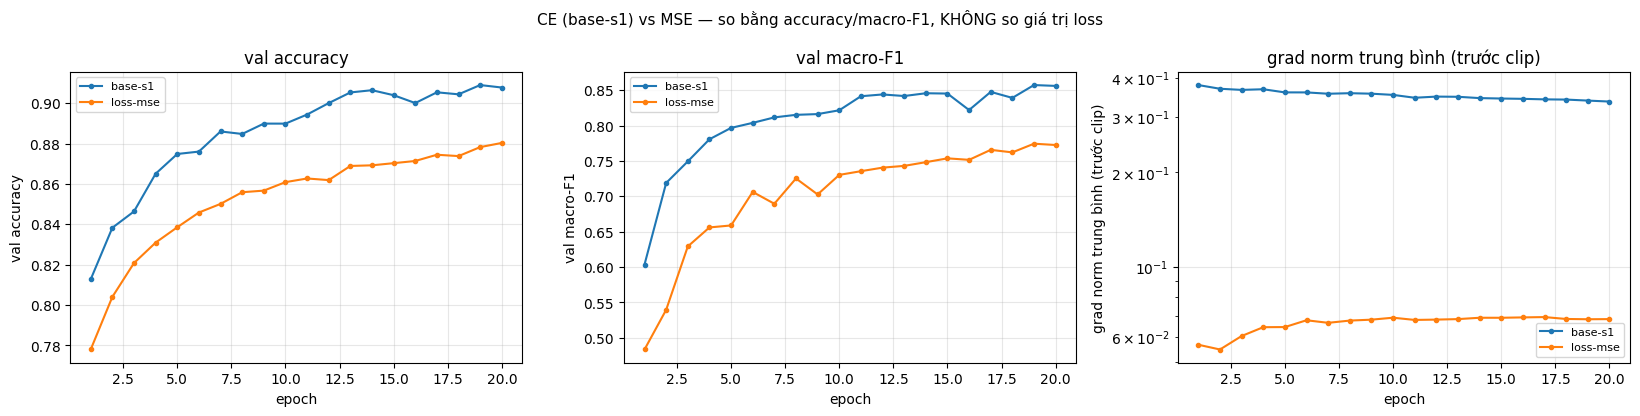

In [10]:
# ===== Chủ đề 1 — Hàm mất mát: CE vs MSE (trên one-hot) =====
loss_ids = run_group("loss", [
    {"exp_id": "loss-mse", "loss": "mse",
     "description": "MSE trên one-hot (nn.MSELoss: trung bình trên B×7 phần tử, không hệ số 1/2)"},
], metrics=("val_acc", "val_macro_f1", "grad_norm"),
   title="CE (base-s1) vs MSE — so bằng accuracy/macro-F1, KHÔNG so giá trị loss")

**Đối chiếu sau khi chạy (`loss-mse`, ảnh `compare_loss.png`):** **khớp dự đoán.** MSE đạt val macro-F1 = 0,7726 (Δ = −0,088 so với trung bình baseline 0,8607, vượt xa 2σ = 0,006) và accuracy 0,8803 (Δ = −0,032). Cơ chế: grad norm trung bình của MSE chỉ 0,066 so với 0,352 của CE (nhỏ hơn ≈ 5 lần), vì gradient theo logit là 2(z − y)/7 và còn bị chia trung bình trên B×7 phần tử, nên mỗi bước nhỏ hơn và model học chậm (best epoch = 20, vẫn đang tăng). Macro-F1 giảm gấp gần 3 lần accuracy: MSE phạt đều cả 7 logit chứ không tập trung vào lớp đúng như softmax + CE, nên các lớp hiếm, vốn ít đóng góp vào loss trung bình, bị bỏ rơi. Không so giá trị loss (MSE 0,027 so với CE 0,23) vì khác thang đo.

### Thí nghiệm `opt-*` — chủ đề `optimizer`
**Dự đoán trước:** mỗi bộ thử ≥ 2 lr (SGD+momentum đã có 4 lr ở Part 2) và so ở lr tốt nhất của từng bộ.
- **SGD thuần** cần lr lớn hơn SGD+momentum khoảng 10 lần mới đi nhanh bằng (momentum 0,9 làm bước hiệu dụng ≈ 10·lr); ở cùng lr = 0,3 sẽ kém rõ rệt.
- **Adam** (lr ≈ 1e-3) sẽ hội tụ nhanh hơn ở vài epoch đầu, vì chia bước theo độ lớn gradient của từng tham số; nhưng ở lr tốt nhất, macro-F1 sau 20 epoch có thể chỉ ngang SGD+momentum (chênh lệch trong nhiễu).
- **AdamW** wd = 0,01 gần như giống Adam: model nhỏ và chưa quá khớp nên suy giảm trọng số ít tác dụng.

[opt-sgd-lr0.3] 47,879 tham số | loss bước 0 (val) = 2.2691 | 727 bước/epoch
  ep  1 | train 0.5322 | val 0.5351 | acc 0.7688 | mF1 0.5273 | gn 0.567 | 1.3s *
  ep  2 | train 0.4789 | val 0.4840 | acc 0.7936 | mF1 0.6337 | gn 0.584 | 1.3s *
  ep  3 | train 0.4606 | val 0.4674 | acc 0.8054 | mF1 0.6168 | gn 0.599 | 1.3s *
  ep  4 | train 0.5374 | val 0.5446 | acc 0.7680 | mF1 0.6530 | gn 0.627 | 1.4s
  ep  5 | train 0.4061 | val 0.4143 | acc 0.8232 | mF1 0.6814 | gn 0.649 | 1.5s *
  ep  6 | train 0.3881 | val 0.3931 | acc 0.8364 | mF1 0.7236 | gn 0.645 | 1.5s *
  ep  7 | train 0.4951 | val 0.4986 | acc 0.7812 | mF1 0.6718 | gn 0.652 | 1.2s
  ep  8 | train 0.3984 | val 0.4081 | acc 0.8303 | mF1 0.6653 | gn 0.667 | 1.3s
  ep  9 | train 0.3383 | val 0.3473 | acc 0.8571 | mF1 0.7094 | gn 0.667 | 1.3s *
  ep 10 | train 0.3915 | val 0.4004 | acc 0.8270 | mF1 0.6948 | gn 0.689 | 1.2s
  ep 11 | train 0.3530 | val 0.3600 | acc 0.8473 | mF1 0.7613 | gn 0.678 | 1.2s
  ep 12 | train 0.3509 | val 0.

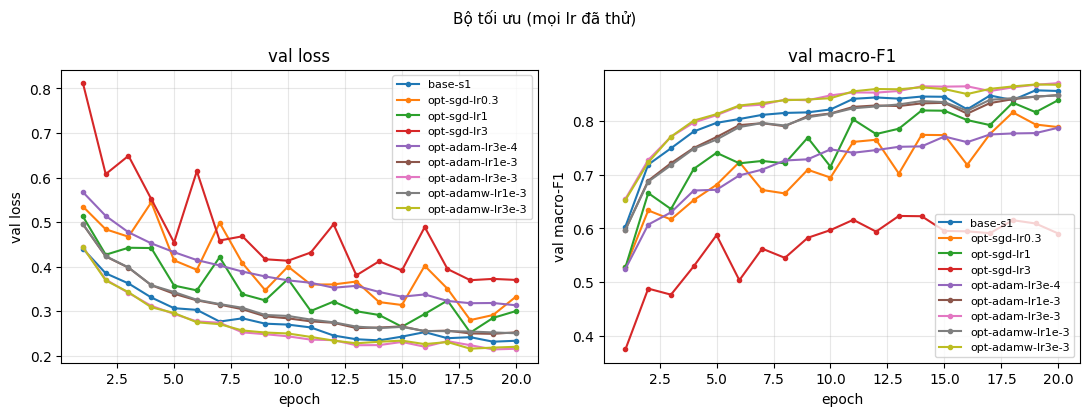


lr tốt nhất của mỗi bộ tối ưu: {'sgd_momentum': 'base-s1', 'sgd': 'opt-sgd-lr1', 'adam': 'opt-adam-lr3e-3', 'adamw': 'opt-adamw-lr3e-3'}


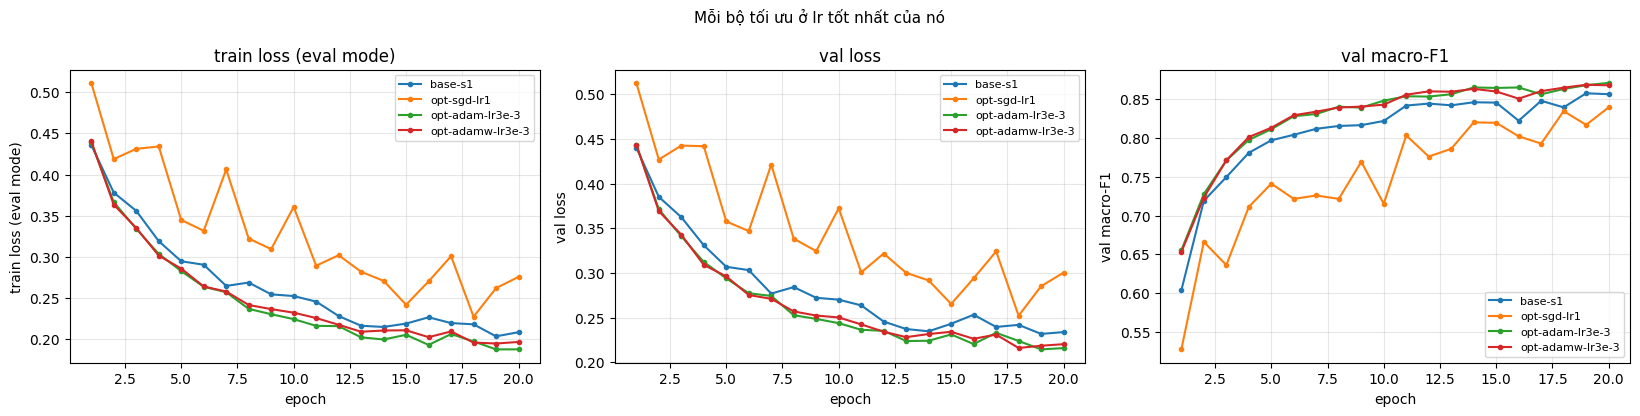

In [11]:
# ===== Chủ đề 2 — Bộ tối ưu: mỗi bộ ≥ 2 lr, so ở lr tốt nhất của từng bộ =====
# SGD+momentum đã dò 4 lr ở Part 2 (hp-sgdm-lr*), tốt nhất lr=BEST_LR (= base-s1).
opt_ids = run_group("optimizer", [
    {"exp_id": "opt-sgd-lr0.3",   "optimizer": "sgd",   "lr": 0.3,  "description": "SGD thuần lr=0.3"},
    {"exp_id": "opt-sgd-lr1",     "optimizer": "sgd",   "lr": 1.0,  "description": "SGD thuần lr=1"},
    {"exp_id": "opt-sgd-lr3",     "optimizer": "sgd",   "lr": 3.0,  "description": "SGD thuần lr=3"},
    {"exp_id": "opt-adam-lr3e-4", "optimizer": "adam",  "lr": 3e-4, "description": "Adam lr=3e-4"},
    {"exp_id": "opt-adam-lr1e-3", "optimizer": "adam",  "lr": 1e-3, "description": "Adam lr=1e-3"},
    {"exp_id": "opt-adam-lr3e-3", "optimizer": "adam",  "lr": 3e-3, "description": "Adam lr=3e-3"},
    {"exp_id": "opt-adamw-lr1e-3", "optimizer": "adamw", "lr": 1e-3, "weight_decay": 0.01,
     "description": "AdamW lr=1e-3, wd=0.01"},
    {"exp_id": "opt-adamw-lr3e-3", "optimizer": "adamw", "lr": 3e-3, "weight_decay": 0.01,
     "description": "AdamW lr=3e-3, wd=0.01"},
], metrics=("val_loss", "val_macro_f1"), title="Bộ tối ưu (mọi lr đã thử)")

# So ở lr tốt nhất (theo val macro-F1) của MỖI bộ tối ưu
def _best(prefix):
    cands = [i for i in RESULTS if i.startswith(prefix) and not RESULTS[i]["summary"]["diverged"]]
    return max(cands, key=lambda i: RESULTS[i]["summary"]["val_macro_f1"])
BEST_PER_OPT = {"sgd_momentum": REF, "sgd": _best("opt-sgd-lr"),
                "adam": _best("opt-adam-lr"), "adamw": _best("opt-adamw-lr")}
print("\nlr tốt nhất của mỗi bộ tối ưu:", BEST_PER_OPT)
plot_compare([RESULTS[i] for i in BEST_PER_OPT.values()],
             ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_optimizer_best.png",
             title="Mỗi bộ tối ưu ở lr tốt nhất của nó", show=True)

**Đối chiếu sau khi chạy (ảnh `compare_optimizer.png`, `compare_optimizer_best.png`):**

| bộ tối ưu | lr đã thử → val macro-F1 | lr tốt nhất | Δ vs baseline |
|---|---|---|---|
| SGD+momentum 0,9 | 0,01→0,761 · 0,03→0,817 · 0,1→0,839 · 0,3→0,857 | 0,3 (`base-s1`) | (baseline, TB 3 seed 0,8607) |
| SGD thuần | 0,3→0,816 · 1→0,834 · 3→0,616 | 1 (`opt-sgd-lr1`) | −0,026 (tệ hơn) |
| Adam | 3e-4→0,788 · 1e-3→0,846 · 3e-3→0,868 | 3e-3 (`opt-adam-lr3e-3`) | +0,007 (sát ngưỡng 2σ) |
| AdamW wd=0,01 | 1e-3→0,848 · 3e-3→0,865 | 3e-3 (`opt-adamw-lr3e-3`) | +0,004 (trong nhiễu) |

- **SGD thuần: lệch một phần so với dự đoán.** Dự đoán "cần lr ×10 để bằng momentum" chỉ đúng một nửa: lr = 1 tốt nhất nhưng vẫn kém baseline, còn lr = 3 (bước hiệu dụng ngang SGD+momentum lr 0,3) lại kém hẳn (0,616), val loss răng cưa mạnh. Momentum không chỉ phóng to bước mà còn **lấy trung bình gradient qua ≈ 10 bước**, làm giảm nhiễu mini-batch; SGD thuần với lr lớn đi trọn từng gradient nhiễu nên dao động.
- **Adam: khớp dự đoán.** Học nhanh hơn ở đầu (epoch 1: macro-F1 0,655 so với 0,604; val loss epoch 5: 0,294 so với 0,307) nhờ chuẩn hoá bước theo từng tham số. Sau 20 epoch chỉ hơn baseline 0,007, vừa chạm ngưỡng 2σ với 1 seed, nên **chưa đủ bằng chứng để nói Adam tốt hơn**.
- **AdamW và Adam: khớp dự đoán.** Ở cả hai lr, chênh lệch đều trong nhiễu (0,846/0,848 và 0,868/0,865): model chưa quá khớp nên suy giảm trọng số không có việc gì để làm.
- Hạn chế: lr tốt nhất của Adam/AdamW (3e-3) là giá trị **lớn nhất đã thử**, nên có thể còn lr tốt hơn.

### Thí nghiệm `hp-*` — chủ đề `hparam`
**Dự đoán trước:**
- **batch 128** (cùng 20 epoch): số bước cập nhật gấp 4 lần (≈ 2 905/epoch so với 727), gradient nhiễu hơn. Có thể đạt macro-F1 cao hơn vì nhiều bước hơn, nhưng mỗi epoch chậm hơn nhiều.
- **batch 2048, giữ lr**: chỉ còn ≈ 182 bước/epoch (ít hơn 4 lần), nên sẽ **chưa học xong** sau 20 epoch, macro-F1 thấp hơn rõ.
- **batch 2048, lr×4 + warmup + cosine** (quy tắc tăng lr theo lô; đổi 3 yếu tố cùng lúc, ghi rõ): bù lại phần lớn số bước bị mất, gần bằng baseline.
- **M-wide / M-deep**: model chưa quá khớp, nên thêm năng lực có thể giúp macro-F1 tăng nhẹ (nhất là M-wide, gấp 3,4 lần tham số), đổi lại chậm hơn một chút.
- **40 epoch**: baseline có best epoch gần cuối (16–19), nên chạy lâu gấp đôi sẽ còn cải thiện.

[hp-batch128] 47,879 tham số | loss bước 0 (val) = 2.2691 | 2906 bước/epoch
  ep  1 | train 0.4818 | val 0.4816 | acc 0.7985 | mF1 0.5729 | gn 0.451 | 5.1s *
  ep  2 | train 0.4490 | val 0.4548 | acc 0.8071 | mF1 0.6768 | gn 0.438 | 5.6s *
  ep  3 | train 0.4601 | val 0.4669 | acc 0.8143 | mF1 0.6435 | gn 0.440 | 5.7s
  ep  4 | train 0.3945 | val 0.4043 | acc 0.8400 | mF1 0.7352 | gn 0.443 | 5.4s *
  ep  5 | train 0.3546 | val 0.3676 | acc 0.8503 | mF1 0.7368 | gn 0.440 | 5.8s *
  ep  6 | train 0.3680 | val 0.3816 | acc 0.8535 | mF1 0.7162 | gn 0.439 | 5.1s
  ep  7 | train 0.3625 | val 0.3729 | acc 0.8579 | mF1 0.7165 | gn 0.441 | 5.7s
  ep  8 | train 0.3349 | val 0.3474 | acc 0.8647 | mF1 0.7764 | gn 0.440 | 5.6s *
  ep  9 | train 0.3860 | val 0.3924 | acc 0.8590 | mF1 0.7696 | gn 0.441 | 5.3s
  ep 10 | train 0.3414 | val 0.3556 | acc 0.8654 | mF1 0.7785 | gn 0.446 | 5.7s
  ep 11 | train 0.3253 | val 0.3399 | acc 0.8687 | mF1 0.7795 | gn 0.440 | 5.1s *
  ep 12 | train 0.3339 | val 0.3

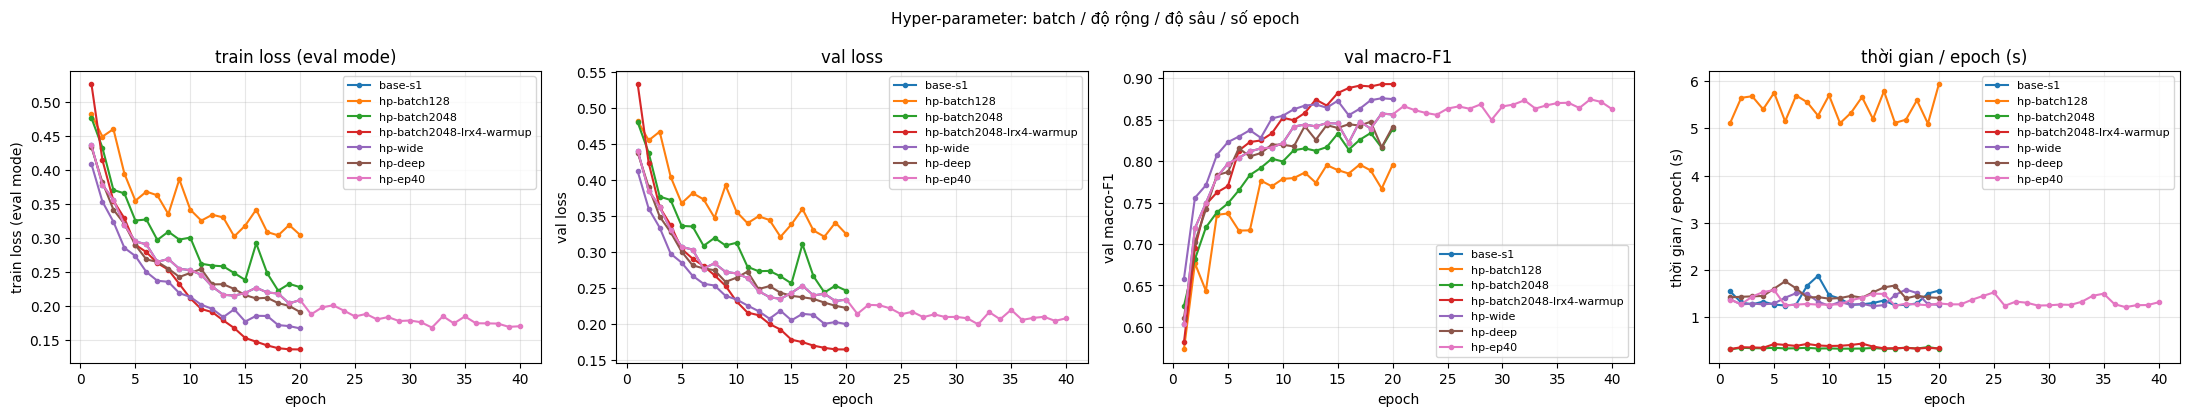

hp-batch128                tổng số bước cập nhật =  58120 |  47,879 tham số
hp-batch2048               tổng số bước cập nhật =   3640 |  47,879 tham số
hp-batch2048-lrx4-warmup   tổng số bước cập nhật =   3640 |  47,879 tham số
hp-wide                    tổng số bước cập nhật =  14540 | 161,287 tham số
hp-deep                    tổng số bước cập nhật =  14540 |  55,687 tham số
hp-ep40                    tổng số bước cập nhật =  29080 |  47,879 tham số


In [12]:
# ===== Chủ đề 3 — Hyper-parameter: batch size, độ rộng, độ sâu, số epoch =====
hp_ids = run_group("hparam", [
    {"exp_id": "hp-batch128",  "batch": 128,  "description": "batch 128 (gấp 4 số bước/epoch)"},
    {"exp_id": "hp-batch2048", "batch": 2048, "description": "batch 2048, giữ nguyên lr"},
    {"exp_id": "hp-batch2048-lrx4-warmup", "batch": 2048, "lr": BASE_CFG["lr"] * 4,
     "scheduler": "warmup_cosine",
     "description": "batch 2048, lr×4 + warmup 5% rồi cosine (quy tắc tăng lr theo lô; ĐỔI 3 YẾU TỐ)"},
    {"exp_id": "hp-wide",  "hidden": (512, 256),     "description": "M-wide 54-512-256-7"},
    {"exp_id": "hp-deep",  "hidden": (256, 128, 64), "description": "M-deep 54-256-128-64-7"},
    {"exp_id": "hp-ep40",  "epochs": 40,             "description": "40 epoch thay vì 20"},
], metrics=("train_loss", "val_loss", "val_macro_f1", "epoch_time_s"),
   title="Hyper-parameter: batch / độ rộng / độ sâu / số epoch")

for i in hp_ids:
    s = RESULTS[i]["summary"]
    print(f"{i:26} tổng số bước cập nhật = {s['total_steps']:>6} | {s['n_params']:>7,} tham số")

**Đối chiếu sau khi chạy (ảnh `compare_hparam.png`):**

| exp_id | số bước | s/epoch | val mF1 | Δ vs TB baseline | so với dự đoán |
|---|---|---|---|---|---|
| `hp-batch128` | 58 120 | 5,22 | 0,7951 | −0,066 | **sai** |
| `hp-batch2048` | 3 640 | 0,35 | 0,8338 | −0,027 | khớp |
| `hp-batch2048-lrx4-warmup` | 3 640 | 0,37 | **0,8928** | **+0,032** | **tốt hơn dự đoán** |
| `hp-wide` (161 287 tham số) | 14 540 | 1,32 | 0,8747 | +0,014 | khớp |
| `hp-deep` (55 687 tham số) | 14 540 | 1,45 | 0,8413 | −0,019 | **sai** |
| `hp-ep40` (best epoch 32) | 29 080 | 1,32 | 0,8733 | +0,013 | khớp |

- **batch 128 kém đi chứ không tốt lên (dự đoán sai).** Dù có gấp 4 số bước, phương sai gradient mini-batch tỉ lệ 1/B, nên mỗi bước nhiễu gấp 4 lần; với lr 0,3 giữ nguyên, SGD bị nhiễu "hất" quanh đáy (val loss tăng ngược ở epoch 3 và 6). Theo quy tắc tăng lr theo lô, batch ÷4 thì nên dùng lr ÷4 (≈ 0,075). Thí nghiệm này không chỉnh lr nên không công bằng với batch nhỏ: đó là hạn chế.
- **batch 2048, giữ lr: khớp.** Chỉ còn 1/4 số bước nên chưa học xong; bù lại nhanh gấp 3,8 lần mỗi epoch.
- **batch 2048 + lr×4 + warmup/cosine: tốt vượt dự đoán**, cao nhất trong mọi thí nghiệm, val loss 0,1646 so với 0,2318. Thí nghiệm này đổi 3 yếu tố cùng lúc nên chưa biết yếu tố nào quyết định. Giả thuyết: **lr giảm dần về 0** ở cuối (cosine) cho phép SGD "đậu" vào đáy thay vì nhảy quanh như với lr 0,3 cố định (đường cuối của nó rất phẳng: 0,167 → 0,165 → 0,165). Mình kiểm tra giả thuyết này bằng `hp-cosine` (chỉ thêm cosine, giữ batch 512) ở ô kế tiếp.
- **M-wide: khớp.** +0,014, gấp hơn 2 lần ngưỡng nhiễu; khoảng cách val − train tăng nhẹ (0,033 so với 0,026), vẫn chưa quá khớp. Thời gian/epoch gần như không đổi (GPU chưa dùng hết sức với mạng nhỏ).
- **M-deep kém hơn (dự đoán sai):** macro-F1 −0,019 dù val loss (0,2222) còn **tốt hơn** `base-s1` (0,2318). Loss và macro-F1 mâu thuẫn nhau, cho thấy khác biệt nằm ở vài lớp hiếm mà loss trung bình không phản ánh. *Phỏng đoán (chưa kiểm chứng):* lớp 64 nơ-ron tạo "nút cổ chai". Chỉ 1 seed nên chưa kết luận được cơ chế.
- **40 epoch: khớp.** 20 epoch đầu trùng khớp tuyệt đối với `base-s1` (cùng seed, xác nhận code tái lập được); best epoch 32 với macro-F1 0,8733 (+0,013). Đến epoch 40 macro-F1 lại dao động xuống 0,862, đúng hiện tượng nhảy quanh đáy khi lr cố định.

### Thí nghiệm `drop-*` — chủ đề `dropout`
**Dự đoán trước:** ở Part 2, train loss và val loss của baseline gần trùng nhau, tức là **chưa quá khớp**. Dropout là "thuốc" chữa quá khớp, nên ở đây nó sẽ **không giúp**: q càng lớn thì model học càng chậm (mỗi bước chỉ cập nhật một mạng con ngẫu nhiên, gradient nhiễu hơn), macro-F1 sau 20 epoch càng thấp. Khoảng cách val − train sẽ thu hẹp lại, nhưng do train loss tăng chứ không phải val loss giảm. q = 0,1 có thể nằm trong nhiễu; q = 0,5 sẽ tệ hơn rõ.

Mức quá khớp của baseline ở epoch cuối: val loss − train loss = +0.0254
[drop-0.1] 47,879 tham số | loss bước 0 (val) = 2.2691 | 727 bước/epoch
  ep  1 | train 0.4496 | val 0.4527 | acc 0.8045 | mF1 0.6019 | gn 0.335 | 1.4s *
  ep  2 | train 0.3921 | val 0.3955 | acc 0.8310 | mF1 0.7082 | gn 0.306 | 1.6s *
  ep  3 | train 0.3701 | val 0.3729 | acc 0.8435 | mF1 0.7166 | gn 0.305 | 1.7s *
  ep  4 | train 0.3367 | val 0.3427 | acc 0.8577 | mF1 0.7568 | gn 0.304 | 1.6s *
  ep  5 | train 0.3212 | val 0.3254 | acc 0.8635 | mF1 0.7587 | gn 0.300 | 1.3s *
  ep  6 | train 0.3067 | val 0.3144 | acc 0.8689 | mF1 0.7793 | gn 0.300 | 1.4s *
  ep  7 | train 0.2921 | val 0.3005 | acc 0.8745 | mF1 0.8010 | gn 0.297 | 1.4s *
  ep  8 | train 0.2820 | val 0.2931 | acc 0.8784 | mF1 0.7942 | gn 0.294 | 1.4s *
  ep  9 | train 0.2766 | val 0.2869 | acc 0.8807 | mF1 0.7976 | gn 0.293 | 1.4s *
  ep 10 | train 0.2707 | val 0.2825 | acc 0.8839 | mF1 0.8145 | gn 0.293 | 1.4s *
  ep 11 | train 0.2649 | val 0.2774 

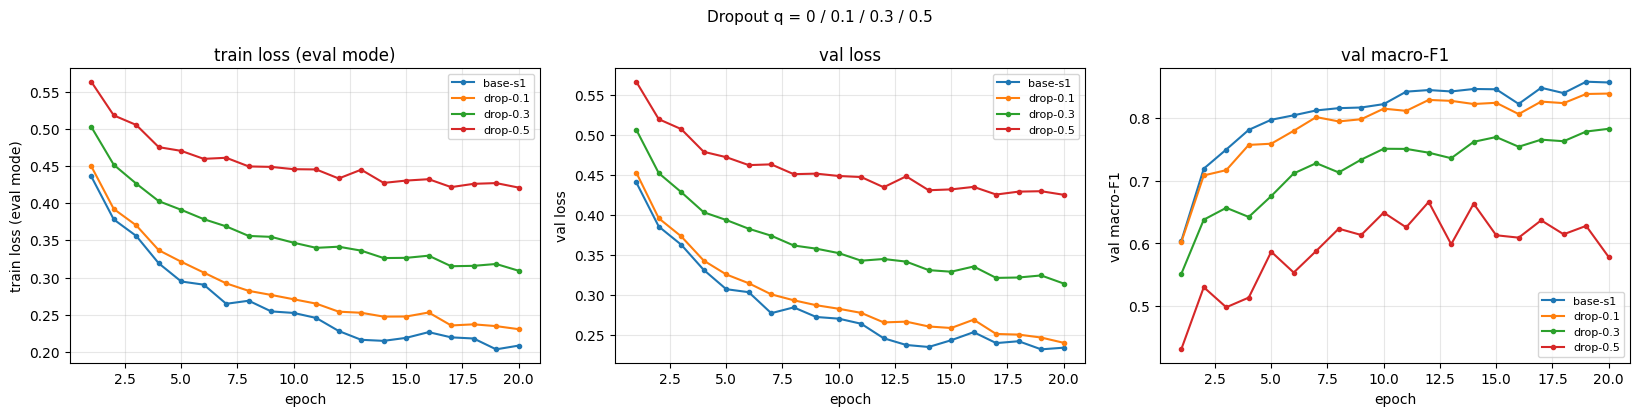

base-s1    khoảng cách val − train loss (epoch cuối) = +0.0254
drop-0.1   khoảng cách val − train loss (epoch cuối) = +0.0095
drop-0.3   khoảng cách val − train loss (epoch cuối) = +0.0050
drop-0.5   khoảng cách val − train loss (epoch cuối) = +0.0040


In [13]:
# ===== Chủ đề 4 — Dropout =====
r0 = RESULTS[REF]["history"]
print(f"Mức quá khớp của baseline ở epoch cuối: val loss − train loss = "
      f"{r0['val_loss'][-1] - r0['train_loss'][-1]:+.4f}")
drop_ids = run_group("dropout", [
    {"exp_id": f"drop-{q}", "dropout": q, "description": f"dropout q={q} sau mỗi ReLU ẩn"}
    for q in (0.1, 0.3, 0.5)
], metrics=("train_loss", "val_loss", "val_macro_f1"), title="Dropout q = 0 / 0.1 / 0.3 / 0.5")

for i in [REF] + drop_ids:
    h = RESULTS[i]["history"]
    print(f"{i:10} khoảng cách val − train loss (epoch cuối) = {h['val_loss'][-1] - h['train_loss'][-1]:+.4f}")

**Đối chiếu sau khi chạy (ảnh `compare_dropout.png`):** **khớp hướng dự đoán**, nhưng tác hại mạnh hơn dự kiến.

| q | val mF1 | Δ vs TB baseline | val − train loss (epoch cuối) |
|---|---|---|---|
| 0 (`base-s1`) | 0,8573 | — | +0,026 |
| 0,1 (`drop-0.1`) | 0,8385 | −0,022 | +0,0095 |
| 0,3 (`drop-0.3`) | 0,7824 | −0,078 | +0,0050 |
| 0,5 (`drop-0.5`) | 0,5784 | −0,282 | +0,0040 |

Khoảng cách val − train thu hẹp khi q tăng, nhưng là vì **train loss tăng lên** (0,208 → 0,231 → 0,309 → 0,421) chứ val loss không giảm. Baseline vốn chưa quá khớp (khoảng cách chỉ 0,026), nên dropout không có gì để chữa, chỉ làm mỗi bước cập nhật một mạng con ngẫu nhiên, gradient nhiễu hơn, model học chậm hơn (cả 3 lần chạy đều có best epoch = 20). Dự đoán "q = 0,1 có thể trong nhiễu" sai: q = 0,1 đã kém 0,022, gấp gần 4 lần ngưỡng nhiễu.

### Thí nghiệm `clip-*` — chủ đề `clipping`
**Dự đoán trước:** chọn ngưỡng c dựa trên grad norm của baseline (trung bình ≈ 0,33, lớn nhất mỗi epoch ≈ 0,4–0,7, gai epoch 1 ≈ 2,5):
- **c = 0,5**: chỉ cắt các gai, phần lớn bước không bị đụng tới, nên kết quả **trong nhiễu** so với baseline.
- **c = 0,25**: thấp hơn mức trung bình, cắt gần như mọi bước, biến SGD thành "bước có độ dài cố định". Bước nhỏ đi nên có thể học chậm hơn một chút.
- **Thí nghiệm phản chứng ở lr ×10 (= 3,0)**: không clip thì huấn luyện sẽ dao động mạnh, sụp về đoán lớp đa số hoặc ra NaN; **có clip c = 0,5** thì độ dài mỗi bước bị chặn trên (≤ lr·c), nên ổn định hơn rõ. Đây mới là tình huống clipping thực sự dùng tới.

Baseline: grad norm trung bình 0.352, lớn nhất mỗi epoch từ 0.518 đến 2.844
[clip-0.5] 47,879 tham số | loss bước 0 (val) = 2.2691 | 727 bước/epoch
  ep  1 | train 0.4200 | val 0.4256 | acc 0.8193 | mF1 0.6203 | gn 0.431 | 1.3s *
  ep  2 | train 0.3650 | val 0.3727 | acc 0.8430 | mF1 0.7243 | gn 0.384 | 1.3s *
  ep  3 | train 0.3371 | val 0.3478 | acc 0.8527 | mF1 0.7580 | gn 0.372 | 1.3s *
  ep  4 | train 0.3139 | val 0.3269 | acc 0.8653 | mF1 0.7924 | gn 0.372 | 1.4s *
  ep  5 | train 0.2931 | val 0.3066 | acc 0.8745 | mF1 0.7981 | gn 0.363 | 1.5s *
  ep  6 | train 0.2758 | val 0.2897 | acc 0.8826 | mF1 0.8057 | gn 0.363 | 1.5s *
  ep  7 | train 0.2589 | val 0.2734 | acc 0.8872 | mF1 0.8182 | gn 0.358 | 1.3s *
  ep  8 | train 0.2533 | val 0.2704 | acc 0.8935 | mF1 0.8243 | gn 0.355 | 1.3s *
  ep  9 | train 0.2443 | val 0.2631 | acc 0.8948 | mF1 0.8303 | gn 0.357 | 1.3s *
  ep 10 | train 0.2458 | val 0.2695 | acc 0.8930 | mF1 0.8203 | gn 0.353 | 1.3s
  ep 11 | train 0.2305 | val 0.248

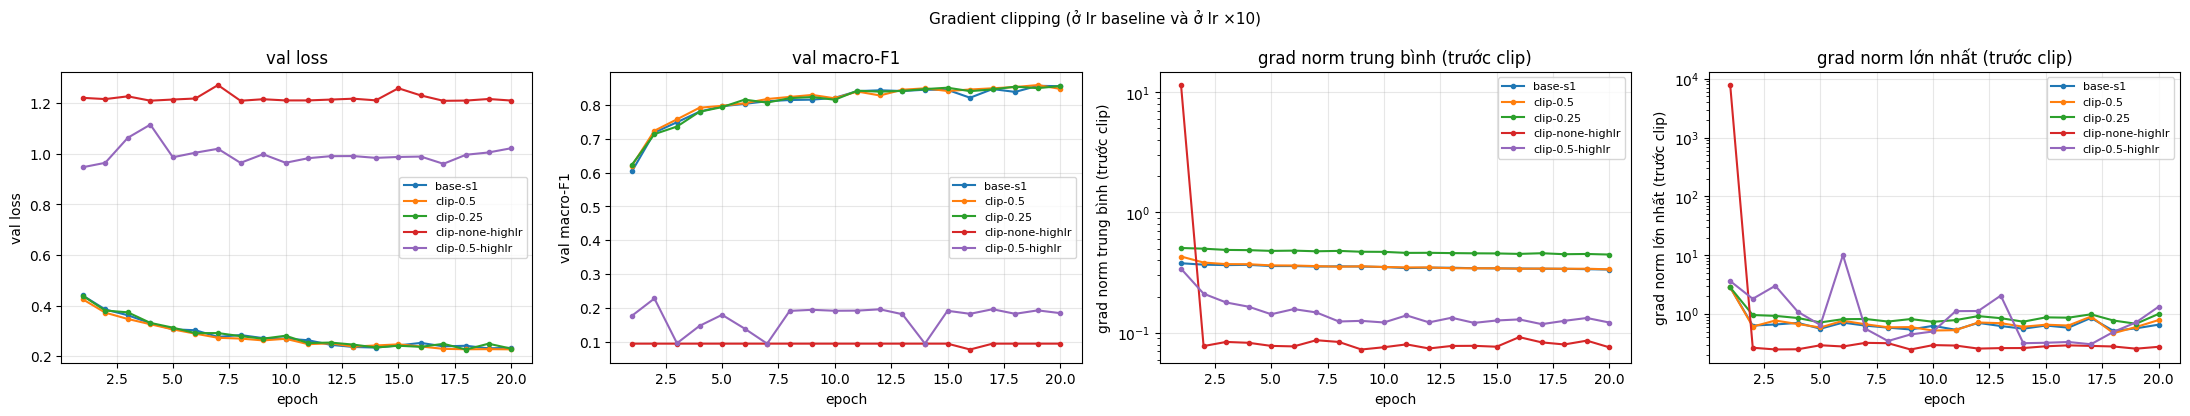

clip-0.5           tỉ lệ bước bị cắt = 1.4% | diverged = False 
clip-0.25          tỉ lệ bước bị cắt = 100.0% | diverged = False 
clip-none-highlr   tỉ lệ bước bị cắt = 0.0% | diverged = False 
clip-0.5-highlr    tỉ lệ bước bị cắt = 1.1% | diverged = False 


In [14]:
# ===== Chủ đề 5 — Gradient clipping =====
gn = RESULTS[REF]["history"]["grad_norm"]
gm = RESULTS[REF]["history"]["grad_norm_max"]
print(f"Baseline: grad norm trung bình {np.mean(gn):.3f}, lớn nhất mỗi epoch từ {min(gm):.3f} đến {max(gm):.3f}")
HIGH_LR = BASE_CFG["lr"] * 10
clip_ids = run_group("clipping", [
    {"exp_id": "clip-0.5",  "clip_norm": 0.5,  "description": "c=0.5 (trên mức trung bình, chỉ cắt các gai)"},
    {"exp_id": "clip-0.25", "clip_norm": 0.25, "description": "c=0.25 (dưới mức trung bình, cắt phần lớn bước)"},
    {"exp_id": "clip-none-highlr", "lr": HIGH_LR, "description": f"lr={HIGH_LR:g} (×10), KHÔNG clip"},
    {"exp_id": "clip-0.5-highlr",  "lr": HIGH_LR, "clip_norm": 0.5,
     "description": f"lr={HIGH_LR:g} (×10), clip c=0.5"},
], metrics=("val_loss", "val_macro_f1", "grad_norm", "grad_norm_max"),
   title="Gradient clipping (ở lr baseline và ở lr ×10)")

for i in clip_ids:
    s = RESULTS[i]["summary"]
    print(f"{i:18} tỉ lệ bước bị cắt = {s['clip_frac']:.1%} | diverged = {s['diverged']} {s['diverged_at'] or ''}")

**Đối chiếu sau khi chạy (ảnh `compare_clipping.png`):** baseline có grad norm trung bình 0,352, lớn nhất mỗi epoch 0,47–0,91, riêng epoch 1 có gai 2,84.

| exp_id | tỉ lệ bước bị cắt | val mF1 | Δ vs TB baseline |
|---|---|---|---|
| `clip-0.5` | 1,4% | 0,8481 | −0,013 |
| `clip-0.25` | 100% | 0,8547 | −0,006 (sát ngưỡng) |
| `clip-none-highlr` (lr 3) | 0% | 0,0936 | sụp |
| `clip-0.5-highlr` (lr 3) | 1,1% | 0,1761 | gần như sụp |

- **c = 0,5:** chỉ cắt 1,4% số bước (các gai), nên về cơ chế gần như không tác động. Macro-F1 thấp hơn 0,013, vượt ngưỡng 2σ theo quy tắc, nhưng val loss (0,2279) lại **tốt hơn** `base-s1` (0,2318). Hai chỉ số mâu thuẫn, và dao động giữa các epoch trong cùng một lần chạy cũng ≈ 0,015 (ví dụ `base-s3`: 0,863 ở best epoch, 0,848 ở epoch cuối). Mình kết luận **không có tác dụng thực**: cắt 1,4% bước chỉ làm quỹ đạo rẽ sang một nhánh ngẫu nhiên khác. Điều này cũng cho thấy ngưỡng 2σ ước lượng từ 3 seed có lẽ đang **đánh giá thấp** độ nhiễu thật.
- **c = 0,25:** cắt mọi bước, biến SGD thành "bước có độ dài cố định lr·c"; kết quả gần baseline, khớp dự đoán.
- **lr × 10 = 3, không clip: khớp dự đoán "sụp".** Không ra NaN, nhưng ở epoch 1 có bước với grad norm ≈ 7 800, đẩy trọng số đi rất xa. Sau đó grad norm chỉ còn ≈ 0,08 và model kẹt ở đoán lớp đa số (acc 0,4876) suốt 20 epoch: dấu hiệu nhiều nơ-ron ReLU "chết" (luôn ra 0 nên không còn gradient).
- **lr × 10 có clip c = 0,5: chỉ khớp một phần.** Clip chặn được cú gai thảm hoạ (grad norm lớn nhất epoch 1 chỉ 3,6), model không chết và vẫn học được chút ít, nhưng macro-F1 chỉ 0,18. Lý do: clip giới hạn mỗi gradient ≤ 0,5, nhưng bước cập nhật = lr × vận tốc momentum, có thể tới ≈ 3 × 0,5 × 10 = 15, vẫn quá lớn. **Clipping chữa được gai gradient thỉnh thoảng xảy ra, không chữa được lr quá lớn một cách hệ thống.**

### Thí nghiệm `amp-*` — chủ đề `amp`
**Dự đoán trước:** độ chính xác FP16 và BF16 sẽ **trong nhiễu** so với FP32 (tham số vẫn giữ FP32, chỉ phép toán hạ độ chính xác; loss tính bằng FP32). Nhưng **không nhanh hơn**, thậm chí chậm hơn: mạng chỉ có 48 nghìn tham số, mỗi phép nhân ma trận rất nhỏ, nên thời gian bị chi phối bởi chi phí gọi kernel chứ không phải tính toán; autocast còn thêm bước ép kiểu, FP16 thêm GradScaler. Bộ nhớ cực đại có thể giảm nhẹ. BF16 có thể chậm hoặc không chạy trên T4, vì T4 không có phần cứng BF16. FP16 cần nhân loss với hệ số s (GradScaler) vì khoảng biểu diễn hẹp (nhỏ nhất ≈ 6e-5, các gradient nhỏ bị tràn dưới về 0); BF16 có cùng số bit mũ với FP32 nên khoảng biểu diễn rộng, thường không cần.

GPU: Tesla T4
torch.cuda.is_bf16_supported(): True
[amp-fp16] 47,879 tham số | loss bước 0 (val) = 2.2691 | 727 bước/epoch
  ep  1 | train 0.4350 | val 0.4378 | acc 0.8138 | mF1 0.6068 | gn 0.378 | 2.0s *
  ep  2 | train 0.3772 | val 0.3794 | acc 0.8402 | mF1 0.7306 | gn 0.368 | 2.0s *
  ep  3 | train 0.3552 | val 0.3610 | acc 0.8484 | mF1 0.7382 | gn 0.366 | 1.7s *
  ep  4 | train 0.3150 | val 0.3263 | acc 0.8655 | mF1 0.7854 | gn 0.367 | 1.7s *
  ep  5 | train 0.3119 | val 0.3223 | acc 0.8663 | mF1 0.7866 | gn 0.355 | 1.7s *
  ep  6 | train 0.2756 | val 0.2863 | acc 0.8822 | mF1 0.8149 | gn 0.356 | 1.7s *
  ep  7 | train 0.2630 | val 0.2758 | acc 0.8875 | mF1 0.8173 | gn 0.353 | 1.7s *
  ep  8 | train 0.2710 | val 0.2863 | acc 0.8840 | mF1 0.8220 | gn 0.351 | 1.8s
  ep  9 | train 0.2477 | val 0.2613 | acc 0.8955 | mF1 0.8272 | gn 0.354 | 2.0s *
  ep 10 | train 0.2488 | val 0.2672 | acc 0.8945 | mF1 0.8269 | gn 0.347 | 2.0s
  ep 11 | train 0.2356 | val 0.2535 | acc 0.8976 | mF1 0.8331

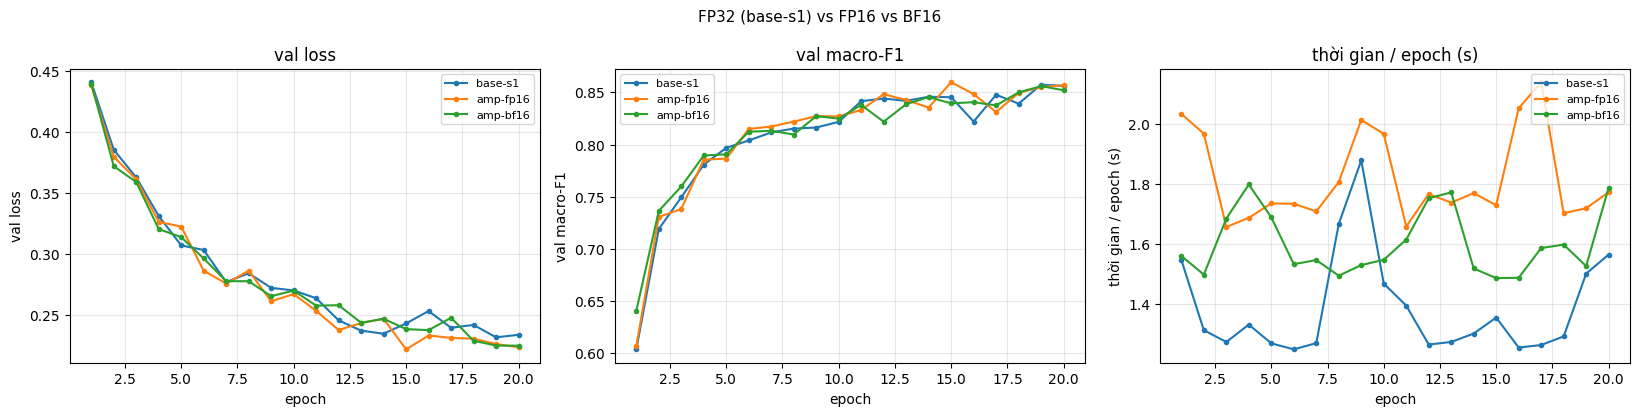


exp_id     | s/epoch | peak MB | val mF1
base-s1    |    1.39 |   162.1 | 0.8573
amp-fp16   |    1.82 |   162.0 | 0.8597
amp-bf16   |    1.60 |   162.0 | 0.8520


In [15]:
# ===== Chủ đề 6 — Mixed precision =====
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "không có")
print("torch.cuda.is_bf16_supported():", torch.cuda.is_bf16_supported() if torch.cuda.is_available() else None)
amp_ids = run_group("amp", [
    {"exp_id": "amp-fp16", "precision": "fp16", "description": "autocast FP16 + GradScaler"},
    {"exp_id": "amp-bf16", "precision": "bf16", "description": "autocast BF16, không GradScaler"},
], metrics=("val_loss", "val_macro_f1", "epoch_time_s"), title="FP32 (base-s1) vs FP16 vs BF16")

print(f"\n{'exp_id':10} | s/epoch | peak MB | val mF1")
for i in [REF] + amp_ids:
    s = RESULTS[i]["summary"]
    print(f"{i:10} | {s['time_per_epoch_s']:7.2f} | {s['peak_mem_MB']:7.1f} | {s['val_macro_f1']:.4f}")

**Đối chiếu sau khi chạy (ảnh `compare_amp.png`):** **khớp dự đoán.**

| exp_id | s/epoch | peak MB | val mF1 | Δ vs TB baseline |
|---|---|---|---|---|
| `base-s1` (FP32) | 1,34 | 162,2 | 0,8573 | — |
| `amp-fp16` | 1,79 (+34%) | 162,2 | 0,8597 | −0,001 (trong nhiễu) |
| `amp-bf16` | 1,60 (+19%) | 162,2 | 0,8520 | −0,009 |

- **Chậm hơn chứ không nhanh hơn:** mạng chỉ 48 nghìn tham số, mỗi phép nhân ma trận quá nhỏ để Tensor Core có lợi; thời gian bị chi phối bởi chi phí gọi kernel, và autocast thêm các bước ép kiểu, FP16 thêm GradScaler (scale, unscale, kiểm tra inf).
- **Bộ nhớ không đổi:** 162 MB chủ yếu là toàn bộ dữ liệu đã nạp sẵn lên GPU (≈ 581 nghìn × 54 × 4 byte ≈ 125 MB); kích hoạt của mạng nhỏ không đáng kể.
- **Độ chính xác:** FP16 trong nhiễu. BF16 thấp hơn 0,009 (1 seed, sát ngưỡng); BF16 chỉ có 8 bit phần định trị (≈ 2–3 chữ số thập phân), kém FP16 (11 bit), nên sai số làm tròn lớn hơn. *Đây là phỏng đoán, cần thêm seed để khẳng định.* T4 không có phần cứng BF16 nên phép toán BF16 được giả lập, thêm một lý do chậm.
- FP16 cần GradScaler vì giá trị dương nhỏ nhất ≈ 6e-5 (dạng chuẩn), các gradient nhỏ sẽ tràn dưới về 0; BF16 có 8 bit mũ như FP32 (khoảng tới ≈ 1e-38) nên thường không cần.

### Thí nghiệm `init-*` — chủ đề `init`
**Dự đoán trước:**
- **zeros**: mọi W = 0 thì mọi nơ-ron trong một lớp giống hệt nhau (đối xứng), và vì ReLU(0) = 0, kích hoạt ẩn bằng 0, nên gradient của W1, W2, W3, b1, b2 đều bằng 0. Chỉ bias lớp ra học được, model sẽ chỉ học được tỉ lệ lớp: **kẹt ở đoán lớp đa số** (acc ≈ 0,4876, macro-F1 ≈ 0,094), loss bước 0 = ln 7 đúng tuyệt đối.
- **normal (std 0,01)**: tín hiệu co lại qua mỗi lớp (std kích hoạt giảm mạnh theo độ sâu), logit gần 0 nên loss bước 0 ≈ ln 7, gradient lớp đầu rất nhỏ. Model học chậm ở các epoch đầu nhưng mạng chỉ có 3 lớp nên vẫn học được.
- **xavier** (Var = 2/(n_in+n_out)) và **default** (U(±1/√n_in)): std kích hoạt giảm dần qua các lớp nhưng không sụp; kết quả cuối có thể gần He. Mạng 3 lớp có lẽ chưa đủ sâu để thấy khác biệt lớn như ví dụ "30 lớp ReLU" trong slide.
- **he** (baseline): std kích hoạt giữ ổn định qua các lớp, đúng thiết kế cho ReLU.

init     | std ReLU1 | std ReLU2 | std logit | loss bước 0 (val)
zeros    |    0.0000 |    0.0000 |    0.0000 | 1.9459
normal   |    0.0203 |    0.0022 |    0.0003 | 1.9460
xavier   |    0.1628 |    0.1248 |    0.1916 | 2.0222
he       |    0.3901 |    0.3661 |    0.5773 | 2.2691
default  |    0.1603 |    0.0678 |    0.0585 | 1.9830
[init-zeros] 47,879 tham số | loss bước 0 (val) = 1.9459 | 727 bước/epoch
  ep  1 | train 1.2035 | val 1.2066 | acc 0.4876 | mF1 0.0936 | gn 0.044 | 1.5s *
  ep  2 | train 1.2039 | val 1.2076 | acc 0.4876 | mF1 0.0936 | gn 0.038 | 1.3s
  ep  3 | train 1.2019 | val 1.2053 | acc 0.4876 | mF1 0.0936 | gn 0.040 | 1.4s *
  ep  4 | train 1.2024 | val 1.2056 | acc 0.4876 | mF1 0.0936 | gn 0.037 | 1.4s
  ep  5 | train 1.2025 | val 1.2058 | acc 0.4876 | mF1 0.0936 | gn 0.038 | 1.3s
  ep  6 | train 1.2028 | val 1.2063 | acc 0.4876 | mF1 0.0936 | gn 0.038 | 1.3s
  ep  7 | train 1.2024 | val 1.2059 | acc 0.4876 | mF1 0.0936 | gn 0.038 | 1.3s
  ep  8 | train 1.2027 | va

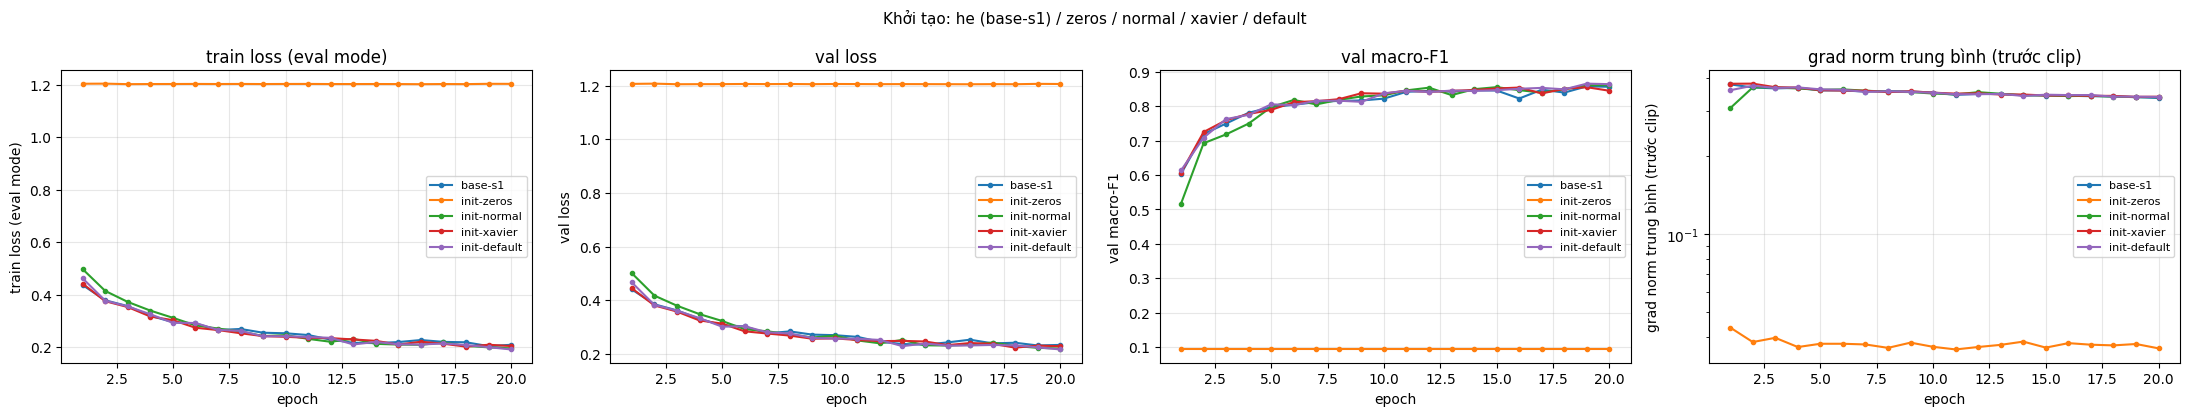

In [16]:
# ===== Chủ đề 7 — Khởi tạo tham số =====
# (a) Bước 0: std kích hoạt sau mỗi ReLU và của logit, loss bước 0 — cùng seed 1, cùng lô val
xb_val = D["X_val"][:4096]
print(f"{'init':8} | std ReLU1 | std ReLU2 | std logit | loss bước 0 (val)")
for init in ("zeros", "normal", "xavier", "he", "default"):
    torch.manual_seed(1)
    m = MLP(hidden=(256, 128), init=init).to(device)
    st = activation_stats(m, xb_val)
    with torch.no_grad():
        l0 = F.cross_entropy(m.eval()(D["X_val"]), D["y_val"]).item()
    print(f"{init:8} | {st[0]:9.4f} | {st[1]:9.4f} | {st[2]:9.4f} | {l0:.4f}")

# (b) Huấn luyện đủ 20 epoch với từng cách khởi tạo (he = base-s1)
init_ids = run_group("init", [
    {"exp_id": "init-zeros",   "init": "zeros",   "description": "W=0, b=0"},
    {"exp_id": "init-normal",  "init": "normal",  "description": "W~N(0, 0.01²), b=0"},
    {"exp_id": "init-xavier",  "init": "xavier",  "description": "xavier_normal_ Var=2/(n_in+n_out), b=0"},
    {"exp_id": "init-default", "init": "default", "description": "mặc định nn.Linear: U(±1/√n_in) (không phải He)"},
], metrics=("train_loss", "val_loss", "val_macro_f1", "grad_norm"),
   title="Khởi tạo: he (base-s1) / zeros / normal / xavier / default")

**Đối chiếu sau khi chạy (ảnh `compare_init.png`):**

| init | std ReLU1 | std ReLU2 | std logit | loss bước 0 | val mF1 | Δ vs TB baseline |
|---|---|---|---|---|---|---|
| zeros | 0 | 0 | 0 | 1,9459 | 0,0936 | sụp |
| normal (0,01) | 0,020 | 0,0022 | 0,0003 | 1,9460 | 0,8609 | +0,000 |
| xavier | 0,163 | 0,125 | 0,192 | 2,0222 | 0,8502 | −0,011 |
| he (`base-s1`) | 0,390 | 0,366 | 0,577 | 2,2691 | 0,8573 | −0,003 |
| default | 0,160 | 0,068 | 0,059 | 1,9830 | 0,8637 | +0,003 |

- **zeros: khớp tuyệt đối.** Kích hoạt ẩn bằng 0, gradient của W1, W2, W3, b1, b2 bằng 0 (grad norm toàn mạng chỉ 0,038, đến từ b3), nên chỉ bias lớp ra học được tỉ lệ lớp: acc = 0,4876, macro-F1 = 0,094, đúng bằng mốc "đoán đa số" trong suốt 20 epoch.
- **normal (0,01): khớp.** Tín hiệu co lại ≈ 10 lần qua mỗi lớp (0,020 → 0,0022 → 0,0003), logit gần 0 nên loss bước 0 = ln 7. Model khởi động chậm (epoch 1: macro-F1 0,517 so với 0,604 của He) nhưng đuổi kịp từ epoch 5, cuối cùng ngang baseline.
- **xavier, default, he:** std kích hoạt của He giữ ổn định qua các lớp (0,39 → 0,37), đúng thiết kế cho ReLU; default và xavier co dần. Nhưng sau 20 epoch, cả ba chênh nhau ≤ 0,011, khoảng mức dao động trong một lần chạy, nên **không kết luận được cách nào tốt hơn**. Với mạng chỉ 3 lớp, tín hiệu co hay giãn vài lần không đủ để chặn việc học, nên không thấy hiện tượng như ví dụ "30 lớp ReLU" của slide. Loss bước 0 lại xếp đúng thứ tự độ lớn logit (std logit càng lớn thì loss bước 0 càng xa ln 7), khớp giải thích ở Part 1.

### Kết hợp và cấu hình cuối cùng — nhóm `final`
**Dự đoán trước:** (1) `hp-cosine` (chỉ thêm cosine, giữ batch 512, lr 0,3): nếu việc giảm lr về 0 là yếu tố chính, nó cũng sẽ vượt baseline rõ. (2) Ứng viên cuối kết hợp các yếu tố tốt theo val: batch 2048 + lr ×4 + warmup/cosine (tốt nhất, +0,032), thêm 40 epoch (+0,013); một ứng viên có thêm M-wide (+0,014). Dự đoán cả hai đạt val macro-F1 ≥ 0,89, M-wide nhỉnh hơn. **Quy tắc chọn, đặt trước khi chạy:** mỗi ứng viên chạy 3 seed, chọn ứng viên có **val macro-F1 trung bình cao nhất**, nộp model **seed 1** của ứng viên đó (không chọn seed). Tập eval không tham gia vào việc chọn.

[hp-cosine] 47,879 tham số | loss bước 0 (val) = 2.2691 | 727 bước/epoch
  ep  1 | train 0.4319 | val 0.4363 | acc 0.8150 | mF1 0.6061 | gn 0.378 | 1.3s *
  ep  2 | train 0.3733 | val 0.3789 | acc 0.8382 | mF1 0.7291 | gn 0.370 | 1.3s *
  ep  3 | train 0.3453 | val 0.3489 | acc 0.8542 | mF1 0.7505 | gn 0.365 | 1.4s *
  ep  4 | train 0.3056 | val 0.3154 | acc 0.8701 | mF1 0.7885 | gn 0.369 | 1.4s *
  ep  5 | train 0.2962 | val 0.3083 | acc 0.8744 | mF1 0.8068 | gn 0.361 | 1.5s *
  ep  6 | train 0.2579 | val 0.2730 | acc 0.8882 | mF1 0.8254 | gn 0.363 | 1.5s *
  ep  7 | train 0.2488 | val 0.2652 | acc 0.8901 | mF1 0.8205 | gn 0.365 | 1.3s *
  ep  8 | train 0.2320 | val 0.2503 | acc 0.8991 | mF1 0.8395 | gn 0.367 | 1.3s *
  ep  9 | train 0.2200 | val 0.2370 | acc 0.9030 | mF1 0.8514 | gn 0.371 | 1.3s *
  ep 10 | train 0.2105 | val 0.2313 | acc 0.9078 | mF1 0.8507 | gn 0.372 | 1.3s *
  ep 11 | train 0.1928 | val 0.2162 | acc 0.9127 | mF1 0.8594 | gn 0.373 | 1.3s *
  ep 12 | train 0.1837 | 

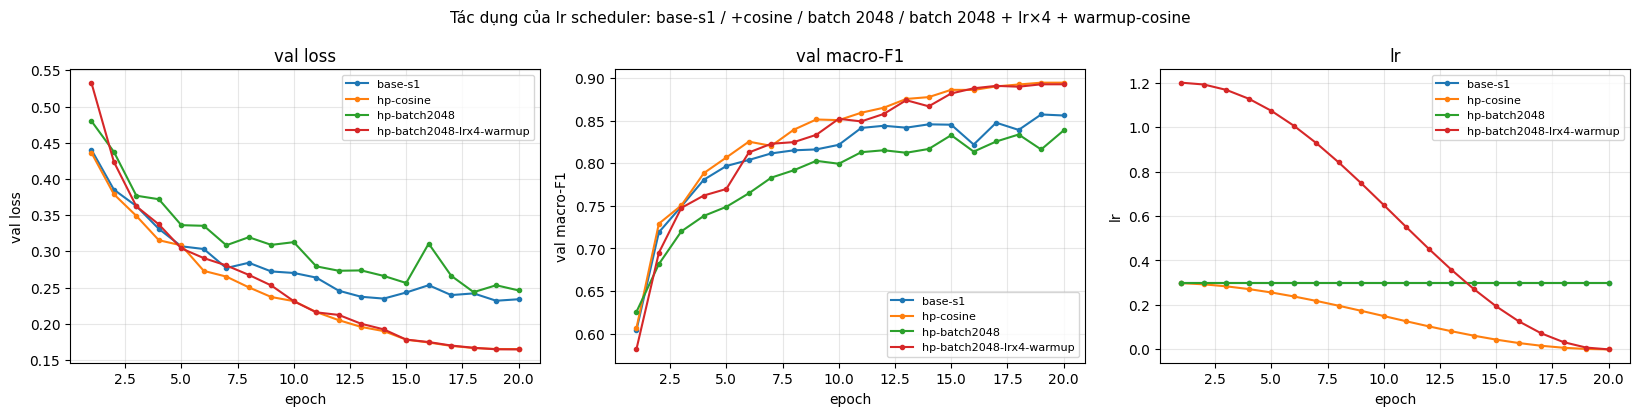

In [17]:
# ===== Bổ sung chủ đề 3: tách riêng tác dụng của lr scheduler (batch 512, lr 0.3, chỉ thêm cosine) =====
run_and_save({**BASE_CFG, "seed": 1, "group": "hparam", "exp_id": "hp-cosine", "scheduler": "cosine",
              "description": "baseline + lr giảm theo cosine về 0 (tách tác dụng scheduler khỏi batch)"})
report(["hp-batch2048", "hp-batch2048-lrx4-warmup", "hp-cosine"])
plot_compare([RESULTS[i] for i in [REF, "hp-cosine", "hp-batch2048", "hp-batch2048-lrx4-warmup"]],
             ["val_loss", "val_macro_f1", "lr"], f"{OUT_DIR}/figures/compare_scheduler.png",
             title="Tác dụng của lr scheduler: base-s1 / +cosine / batch 2048 / batch 2048 + lr×4 + warmup-cosine",
             show=True)

[fin-b2048-wc-ep40-s1] 47,879 tham số | loss bước 0 (val) = 2.2691 | 182 bước/epoch
  ep  1 | train 0.5050 | val 0.5076 | acc 0.7814 | mF1 0.6123 | gn 0.533 | 0.4s *
  ep  2 | train 0.4404 | val 0.4463 | acc 0.8039 | mF1 0.6665 | gn 0.341 | 0.3s *
  ep  3 | train 0.3827 | val 0.3881 | acc 0.8347 | mF1 0.7233 | gn 0.275 | 0.4s *
  ep  4 | train 0.3394 | val 0.3447 | acc 0.8568 | mF1 0.7550 | gn 0.243 | 0.4s *
  ep  5 | train 0.3112 | val 0.3196 | acc 0.8669 | mF1 0.7850 | gn 0.231 | 0.4s *
  ep  6 | train 0.3096 | val 0.3173 | acc 0.8676 | mF1 0.7901 | gn 0.226 | 0.4s *
  ep  7 | train 0.2692 | val 0.2830 | acc 0.8834 | mF1 0.8159 | gn 0.228 | 0.4s *
  ep  8 | train 0.2725 | val 0.2844 | acc 0.8833 | mF1 0.8108 | gn 0.214 | 0.4s
  ep  9 | train 0.2512 | val 0.2663 | acc 0.8906 | mF1 0.8313 | gn 0.216 | 0.4s *
  ep 10 | train 0.2375 | val 0.2534 | acc 0.8960 | mF1 0.8299 | gn 0.215 | 0.4s *
  ep 11 | train 0.2307 | val 0.2524 | acc 0.8987 | mF1 0.8345 | gn 0.207 | 0.4s *
  ep 12 | train 

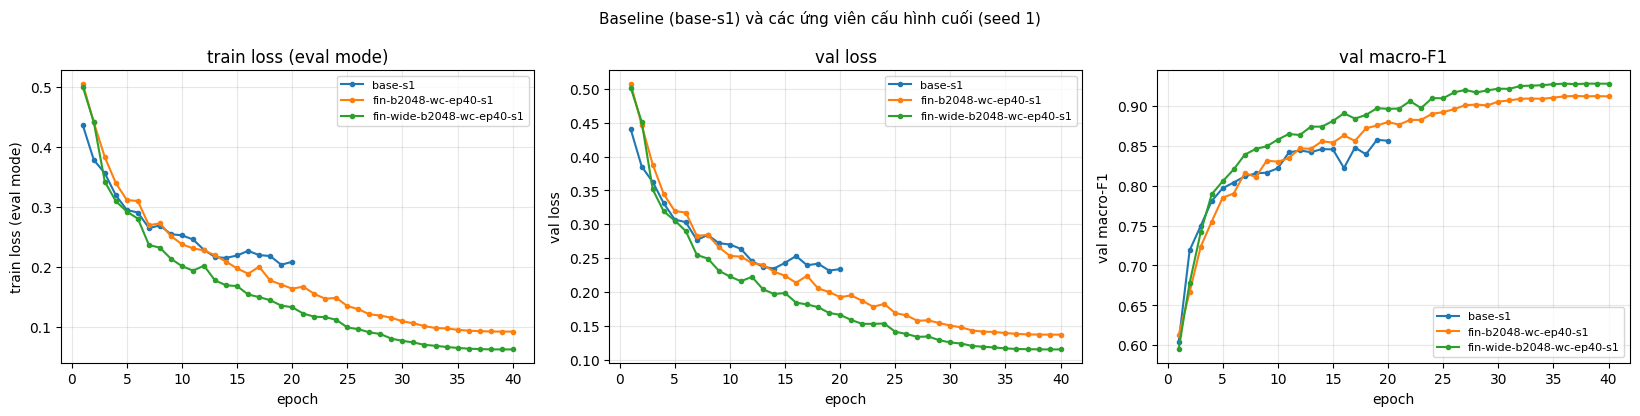

In [18]:
# ===== Cấu hình cuối: chọn CHỈ bằng val, 3 seed cho mỗi ứng viên =====
LR_X4 = BASE_CFG["lr"] * 4
FINAL_CANDS = {
    "fin-b2048-wc-ep40": dict(batch=2048, lr=LR_X4, scheduler="warmup_cosine", epochs=40,
                              description=f"M-base, batch 2048, lr {LR_X4:g}, warmup+cosine, 40 epoch"),
    "fin-wide-b2048-wc-ep40": dict(hidden=(512, 256), batch=2048, lr=LR_X4, scheduler="warmup_cosine",
                                   epochs=40,
                                   description=f"M-wide, batch 2048, lr {LR_X4:g}, warmup+cosine, 40 epoch"),
}
FINAL_SEEDS = [1, 2, 3]
for name, c in FINAL_CANDS.items():
    for s in FINAL_SEEDS:
        run_and_save({**BASE_CFG, **c, "seed": s, "group": "final", "exp_id": f"{name}-s{s}",
                      "description": c["description"] + f", seed {s}"})

print(f"\n{'ứng viên':24} | val mF1 từng seed        | trung bình ± std | Δ vs baseline")
cand_mean = {}
for name in FINAL_CANDS:
    f = np.array([RESULTS[f"{name}-s{s}"]["summary"]["val_macro_f1"] for s in FINAL_SEEDS])
    cand_mean[name] = f.mean()
    print(f"{name:24} | {', '.join(f'{x:.4f}' for x in f)} | {f.mean():.4f} ± {f.std(ddof=1):.4f} | "
          f"{f.mean() - BASE_F1_MEAN:+.4f}")
print(f"{'baseline (base-s1..s3)':24} | {'':24} | {BASE_F1_MEAN:.4f} ± {NOISE_F1/2:.4f} |")

# Quy tắc chọn đặt TRƯỚC: ứng viên có val macro-F1 trung bình cao nhất; nộp model của seed 1 (không chọn seed)
FINAL_NAME = max(cand_mean, key=cand_mean.get)
FINAL_ID = f"{FINAL_NAME}-s1"
print(f"\n=> Cấu hình cuối (chọn theo VAL): {FINAL_NAME}; model nộp: {FINAL_ID}")

plot_compare([RESULTS[REF]] + [RESULTS[f"{n}-s1"] for n in FINAL_CANDS],
             ["train_loss", "val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_final.png",
             title="Baseline (base-s1) và các ứng viên cấu hình cuối (seed 1)", show=True)

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [19]:
# ===== Part 4a — Đánh giá cuối trên EVAL: chỉ cho baseline và cấu hình cuối =====
import json
from train import final_eval
REPO_ROOT = "../.."

for i in ("base-s1", FINAL_ID):
    assert RESULTS.get(i, {}).get("best_state") is not None, \
        f"Không còn trọng số của {i} trong RAM (phiên đã khởi động lại?) -> chạy lại ô tạo ra {i}"

os.makedirs(f"{OUT_DIR}/eval_baseline", exist_ok=True)
print("=" * 30, "BASELINE (base-s1)", "=" * 30)
EV_BASE = final_eval(RESULTS["base-s1"]["cfg"], RESULTS["base-s1"], D,
                     f"{OUT_DIR}/eval_baseline/predictions_eval.csv",
                     repo_root=REPO_ROOT, out_json=f"{OUT_DIR}/eval_baseline/eval_result.json")
print("=" * 30, f"CẤU HÌNH CUỐI ({FINAL_ID})", "=" * 30)
EV_FINAL = final_eval(RESULTS[FINAL_ID]["cfg"], RESULTS[FINAL_ID], D,
                      f"{OUT_DIR}/predictions_eval.csv",
                      repo_root=REPO_ROOT, out_json=f"{OUT_DIR}/eval_result.json")
EVAL_SCORES = {"base-s1": EV_BASE, FINAL_ID: EV_FINAL}

print(f"\n{'':22} | {'val acc':>7} | {'val mF1':>7} | {'eval acc':>8} | {'eval mF1':>8}")
for i, ev in EVAL_SCORES.items():
    s = RESULTS[i]["summary"]
    print(f"{i:22} | {s['val_acc']:.4f} | {s['val_macro_f1']:.4f} | {ev['accuracy']:8.4f} | {ev['macro_f1']:8.4f}")
d = EV_FINAL["macro_f1"] - EV_BASE["macro_f1"]
print(f"\nCải thiện eval macro-F1 so với baseline: {d:+.4f}  (ngưỡng nhiễu seed 2σ trên val = {NOISE_F1:.4f})")

============================== BASELINE (base-s1) ==============================
Đã ghi 116,203 dự đoán -> ../eval_baseline/predictions_eval.csv
n_eval = 116203
accuracy = 0.9089
macro_f1 = 0.8565   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9304  0.8798  0.9044
  1    56661     0.9025  0.9514  0.9263
  2     7151     0.9303  0.8610  0.8943
  3      549     0.8330  0.7723  0.8015
  4     1899     0.8195  0.7077  0.7595
  5     3473     0.7670  0.8557  0.8089
  6     4102     0.9405  0.8632  0.9002

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  37274   4837     1    0    44     9   203
1   2225  53908    87    0   237   183    21
2     13    271  6157   67    14   629     0
3      0      0    57  424     0    68     0
4     26    494    21    0  1344    14     0
5     17    170   295   18     1  2972     0
6    506     55     0    0     0     0  3541

đã ghi /content/drive/MyDrive/K4-Track4-Day1-Neuralnetwor

lớp                    | mẫu train | support | P (cuối) | R (cuối) | F1 (cuối) | F1 (baseline) | ΔF1
0 Spruce/Fir           |   135,578 |  42,368 |   0.9567 |   0.9514 |    0.9540 |        0.9044 | +0.0496
1 Lodgepole Pine       |   181,312 |  56,661 |   0.9601 |   0.9660 |    0.9631 |        0.9263 | +0.0368
2 Ponderosa Pine       |    22,882 |   7,151 |   0.9556 |   0.9565 |    0.9560 |        0.8943 | +0.0617
3 Cottonwood/Willow    |     1,759 |     549 |   0.8929 |   0.8652 |    0.8788 |        0.8015 | +0.0773
4 Aspen                |     6,075 |   1,899 |   0.9015 |   0.8768 |    0.8889 |        0.7595 | +0.1294
5 Douglas-fir          |    11,115 |   3,473 |   0.9182 |   0.9113 |    0.9147 |        0.8089 | +0.1058
6 Krummholz            |    13,126 |   4,102 |   0.9630 |   0.9576 |    0.9603 |        0.9002 | +0.0601

Ma trận nhầm lẫn của cấu hình cuối (hàng = thật, cột = dự đoán), % theo hàng:
            0      1      2      3      4      5      6
    0    95.1    4.5    0.0  

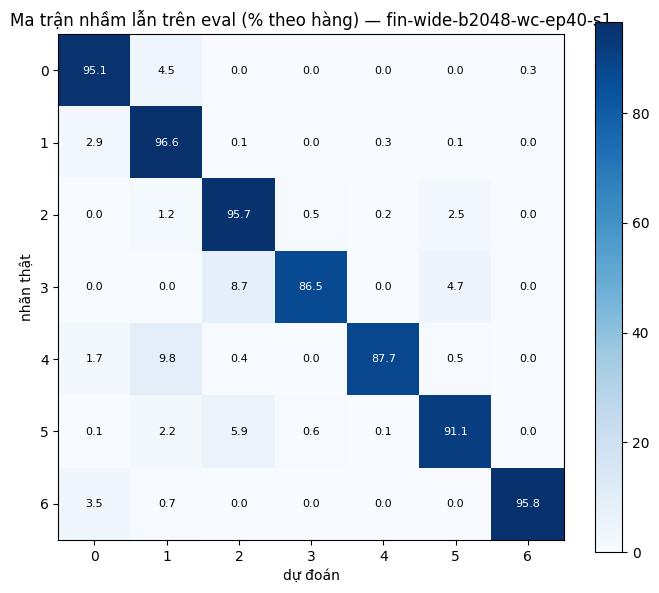

In [20]:
# ===== Part 4b — Phân tích lỗi theo lớp trên EVAL (từ eval_result.json) =====
import matplotlib.pyplot as plt
NAMES = ["0 Spruce/Fir", "1 Lodgepole Pine", "2 Ponderosa Pine", "3 Cottonwood/Willow",
         "4 Aspen", "5 Douglas-fir", "6 Krummholz"]
y_np = D["y_tr"].cpu().numpy()

print(f"{'lớp':22} | {'mẫu train':>9} | support | P (cuối) | R (cuối) | F1 (cuối) | F1 (baseline) | ΔF1")
for pc, pb in zip(EV_FINAL["per_class"], EV_BASE["per_class"]):
    c = pc["cls"]
    print(f"{NAMES[c]:22} | {(y_np == c).sum():9,} | {pc['support']:7,} | {pc['precision']:8.4f} | "
          f"{pc['recall']:8.4f} | {pc['f1']:9.4f} | {pb['f1']:13.4f} | {pc['f1'] - pb['f1']:+.4f}")

cm = np.array(EV_FINAL["confusion_matrix"])
cm_pct = cm / cm.sum(1, keepdims=True) * 100
print("\nMa trận nhầm lẫn của cấu hình cuối (hàng = thật, cột = dự đoán), % theo hàng:")
print("      " + "".join(f"{j:>7d}" for j in range(7)))
for i in range(7):
    print(f"{i:>5d} " + "".join(f"{cm_pct[i, j]:7.1f}" for j in range(7)))

off = [(cm[i, j], i, j) for i in range(7) for j in range(7) if i != j]
print("\n5 cặp nhầm nhiều nhất (thật -> dự đoán):")
for n, i, j in sorted(off, reverse=True)[:5]:
    print(f"  {NAMES[i]:22} -> {NAMES[j]:22}: {n:5,} mẫu ({cm_pct[i, j]:.1f}% của lớp {i})")

worst = int(np.argmin([p["f1"] for p in EV_FINAL["per_class"]]))
print(f"\nLớp khó nhất (F1 thấp nhất): {NAMES[worst]}")

# Lý giải bằng dữ liệu: đặc trưng Elevation (cột 0) theo lớp, đơn vị gốc (m), trên train
elev = D["X_tr"][:, 0].cpu().numpy() * D["std"][0] + D["mean"][0]
print("\nElevation (m) theo lớp trên train: trung bình ± std")
for c in range(7):
    e = elev[y_np == c]
    print(f"  {NAMES[c]:22}: {e.mean():7.0f} ± {e.std():4.0f}")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_pct, cmap="Blues")
for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{cm_pct[i, j]:.1f}", ha="center", va="center",
                color="white" if cm_pct[i, j] > 50 else "black", fontsize=8)
ax.set_xticks(range(7)); ax.set_yticks(range(7))
ax.set_xlabel("dự đoán"); ax.set_ylabel("nhãn thật")
ax.set_title(f"Ma trận nhầm lẫn trên eval (% theo hàng) — {FINAL_ID}")
fig.colorbar(im); plt.tight_layout(); plt.show()

**Đối chiếu sau khi chạy (ảnh `compare_scheduler.png`, `compare_final.png`):**
- `hp-cosine` (chỉ thêm cosine, batch 512, lr 0,3) đạt val macro-F1 0,8947, ngang `hp-batch2048-lrx4-warmup` (0,8928) và hơn baseline +0,034: **khớp giả thuyết**. Yếu tố quyết định là giảm lr dần về 0, cho SGD "đậu" vào đáy thay vì nhảy quanh với lr cố định. Batch 2048 + lr ×4 cho cùng chất lượng nhưng nhanh gấp 3,5 lần mỗi epoch (0,37 s so với 1,31 s).
- Ứng viên cuối (3 seed): M-base 0,9142 ± 0,0019; **M-wide 0,9262 ± 0,0019**, nên chọn M-wide theo đúng quy tắc đặt trước; model nộp là `fin-wide-b2048-wc-ep40-s1` (val macro-F1 0,9277). **Khớp dự đoán** (≥ 0,89, M-wide nhỉnh hơn). Cải thiện so với baseline +0,066, lớn hơn rất nhiều so với ngưỡng nhiễu 0,006 và σ của cả hai phía (≈ 0,002–0,003).
- Khoảng cách val − train loss của cấu hình cuối là 0,053, gấp đôi baseline, nhưng best epoch vẫn là 39–40: chưa quá khớp tới mức có hại.

**Phân tích lỗi (cấu hình cuối `fin-wide-b2048-wc-ep40-s1`, eval):** eval macro-F1 = 0,9308, accuracy = 0,9562; baseline `base-s1`: 0,8565 / 0,9089. Cải thiện +0,074 macro-F1. Val và eval rất gần nhau (lệch +0,003 và −0,001).
- **Lớp khó nhất: lớp 3 Cottonwood/Willow (F1 = 0,8788, precision 0,893, recall 0,865)**, hay bị nhầm thành **lớp 2 Ponderosa Pine (8,7%)** và **lớp 5 Douglas-fir (4,7%)**.
- Lý giải: lớp 3 chỉ có 1 759 mẫu train (0,47%), và elevation của nó (2 224 ± 102 m) chồng lấn với lớp 2 (2 394 ± 196 m) và lớp 5 (2 418 ± 189 m), ba lớp ở độ cao thấp nhất. Recall thấp hơn precision: khi không chắc, model nghiêng về lớp láng giềng nhiều mẫu hơn. Tương tự, lớp 4 Aspen (F1 0,889) bị đoán thành lớp 1 Lodgepole 9,8% vì elevation 2 788 ± 96 m nằm gọn trong khoảng của lớp 1 (2 921 ± 186 m). Về số lượng tuyệt đối, cặp nhầm lớn nhất là 0 ↔ 1 (1 899 + 1 644 mẫu): hai lớp lớn nhất có elevation gần nhau.
- So với baseline, các lớp hiếm cải thiện nhiều nhất (lớp 4 +0,129, lớp 5 +0,106, lớp 3 +0,077), nên macro-F1 tăng nhiều hơn accuracy (+0,074 so với +0,047).
- Cách cải thiện sẽ thử: cross-entropy có trọng số theo lớp (hoặc lấy mẫu lại lớp hiếm), chọn bằng val macro-F1.

In [21]:
# ===== Part 4c — Bảng experiments.xlsx (tạo bằng code từ results/*.json) =====
import results_table as rt_mod
importlib.reload(rt_mod)
from results_table import load_results, to_row, sort_rows, write_xlsx

NOTES = {
    "base-s1": "cùng cấu hình và kết quả với hp-sgdm-lr0.3",
    "hp-sgdm-lr0.3": "lr được chọn cho baseline; = base-s1",
    "hp-batch2048-lrx4-warmup": "ĐỔI 3 YẾU TỐ: batch 2048, lr×4, warmup 5% + cosine",
    "hp-cosine": "chỉ thêm cosine để tách tác dụng scheduler",
    "clip-none-highlr": "không NaN nhưng epoch 1 grad norm max ≈ 7 800 rồi sụp về đoán lớp đa số",
    "amp-bf16": "T4 không có phần cứng BF16",
    FINAL_ID: "CẤU HÌNH CUỐI — model nộp (predictions_eval.csv); chọn theo val trung bình 3 seed",
}
for opt_name, i in BEST_PER_OPT.items():
    NOTES[i] = (NOTES.get(i, "") + f"; lr tốt nhất của {opt_name}").strip("; ")
for i in RESULTS:
    if i.startswith("fin-") and i != FINAL_ID:
        NOTES.setdefault(i, "ứng viên cấu hình cuối (đo độ ổn định qua seed)")
for i, why in SKIPPED.items():
    print(f"Lưu ý: {i} không chạy được ({why}) -> không có dòng trong bảng")

SUMMARY_NOTES = {
    "baseline": f"3 seed: val mF1 = {BASE_F1_MEAN:.4f} ± {NOISE_F1/2:.4f}; ngưỡng nhiễu 2σ = {NOISE_F1:.4f}.",
    "loss": "MSE kém hơn CE rõ (mF1 −0,09): gradient nhỏ (~5 lần), lớp hiếm bị bỏ rơi.",
    "optimizer": "Ở lr tốt nhất: Adam 3e-3 ≈ AdamW ≈ SGD+momentum (chênh ≤ 2σ); SGD thuần kém hơn rõ.",
    "hparam": "Giảm lr theo lịch (cosine) và mạng rộng giúp rõ nhất; batch 128 với lr giữ nguyên thì kém.",
    "dropout": "Baseline chưa quá khớp nên dropout chỉ làm học chậm: q càng lớn mF1 càng thấp.",
    "clipping": "c=0,5 chỉ cắt 1,4% bước (không tác dụng); ở lr×10 clip tránh sụp nhưng không cứu được lr quá lớn.",
    "amp": "Độ chính xác gần FP32; trên T4 với mạng nhỏ, FP16/BF16 CHẬM hơn FP32.",
    "init": "Chỉ zeros thất bại (đối xứng); normal/xavier/default/he gần nhau vì mạng chỉ 3 lớp.",
    "final": f"Cấu hình cuối {FINAL_NAME}: val mF1 trung bình {cand_mean[FINAL_NAME]:.4f} "
             f"(+{cand_mean[FINAL_NAME] - BASE_F1_MEAN:.4f} so với baseline).",
}

results = load_results(f"{OUT_DIR}/results")
rows = sort_rows([to_row(r, EVAL_SCORES.get(r["cfg"]["exp_id"]), NOTES.get(r["cfg"]["exp_id"], ""))
                  for r in results])
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx",
           seed_ids=["base-s1", "base-s2", "base-s3"], summary_notes=SUMMARY_NOTES)

# Kiểm tra: mỗi dòng có đúng 1 ảnh figures/<exp_id>.png và ngược lại
figs = {f[:-4] for f in os.listdir(f"{OUT_DIR}/figures") if f.endswith(".png") and not f.startswith("compare_")}
ids = {r["exp_id"] for r in rows}
print(f"Số dòng bảng = {len(ids)}, số ảnh thí nghiệm = {len(figs)}")
print("Dòng thiếu ảnh:", sorted(ids - figs) or "không")
print("Ảnh thừa (không có dòng):", sorted(figs - ids) or "không")

Đã ghi 42 dòng -> ../experiments.xlsx
Số dòng bảng = 42, số ảnh thí nghiệm = 42
Dòng thiếu ảnh: không
Ảnh thừa (không có dòng): không


In [22]:
# ===== Part 4d — Kiểm tra trước khi nộp =====
import glob, subprocess, sys, shutil
SUB = os.path.abspath(OUT_DIR)
must = ["REPORT.md", "experiments.xlsx", "predictions_eval.csv", "eval_result.json", "figures", "code/lab.ipynb"]
for m in must:
    print(f"{'✅' if os.path.exists(os.path.join(SUB, m)) else '❌'} {m}")
bad = [f for f in glob.glob(f"{SUB}/code/*.py") if "NotImplementedError" in open(f, encoding="utf-8").read()]
print("File .py còn NotImplementedError:", bad or "không")
for p in glob.glob(f"{SUB}/**/__pycache__", recursive=True) + glob.glob(f"{SUB}/**/.ipynb_checkpoints", recursive=True):
    shutil.rmtree(p, ignore_errors=True)       # cache do Python/Jupyter tạo ra, không nộp
junk = [p for p in glob.glob(f"{SUB}/**/*", recursive=True)
        if p.endswith((".pt", ".pth", ".ckpt", ".npz")) or "__pycache__" in p or ".ipynb_checkpoints" in p]
print("File không được nộp:", junk or "không")
out = subprocess.run([sys.executable, "scripts/evaluate.py", "--pred", f"{SUB}/predictions_eval.csv"],
                     cwd=REPO_ROOT, capture_output=True, text=True).stdout
print("\n".join(out.splitlines()[:3]))

✅ REPORT.md
✅ experiments.xlsx
✅ predictions_eval.csv
✅ eval_result.json
✅ figures
✅ code/lab.ipynb
File .py còn NotImplementedError: không
File không được nộp: không
n_eval = 116203
accuracy = 0.9562
macro_f1 = 0.9308   <- chỉ số chính
